<div style="padding:44px 48px;border-radius:26px;background:radial-gradient(circle at 78% 18%,#5e4d91 0,#202a58 35%,#080d20 78%);border:1px solid #8792c8;box-shadow:0 18px 58px rgba(3,7,23,.42)">
  <h1 style="margin:0;color:#f7f1dc;font-size:46px;letter-spacing:.02em;font-weight:760">The Moon Counts Melons</h1>
</div>

In [1]:
from pathlib import Path
import hashlib, importlib.metadata, tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import HTML, display

NAVY="#080d20"; PANEL="#111936"; INK="#f7f1dc"; MUTED="#b5bfdf"
MOON="#f0c86b"; RAIN="#68d6e7"; VIOLET="#b99aea"; CLAY="#df806c"; GREEN="#78c98a"
plt.rcParams.update({
    "figure.facecolor":NAVY,"axes.facecolor":PANEL,"savefig.facecolor":NAVY,
    "text.color":INK,"axes.labelcolor":MUTED,"axes.edgecolor":"#59668f",
    "xtick.color":MUTED,"ytick.color":MUTED,"axes.titleweight":"bold",
    "axes.titlesize":14,"font.size":11,"grid.color":"#3d496e","grid.alpha":.42,
})
print("kaggle-environments", importlib.metadata.version("kaggle-environments"))

kaggle-environments 1.29.3


## Start with every public loss

The public episode index now gives a useful adversarial laboratory: 644 symmetric games against eight strong public teams, with every preserved policy replayed on its recorded seed in both seats. Moon V14 won 622. Its 22 failures were not one problem: some were visible weed collisions, some were market-timing mismatches, and some were terminal edges measured in tens of coins.

The new policy changes only two narrow pieces. It delays a public market counterfactual until four shops and the live money gap identify one of three observed economic regimes, and it uses one terminal market splice behind a separate visible shop prefix.

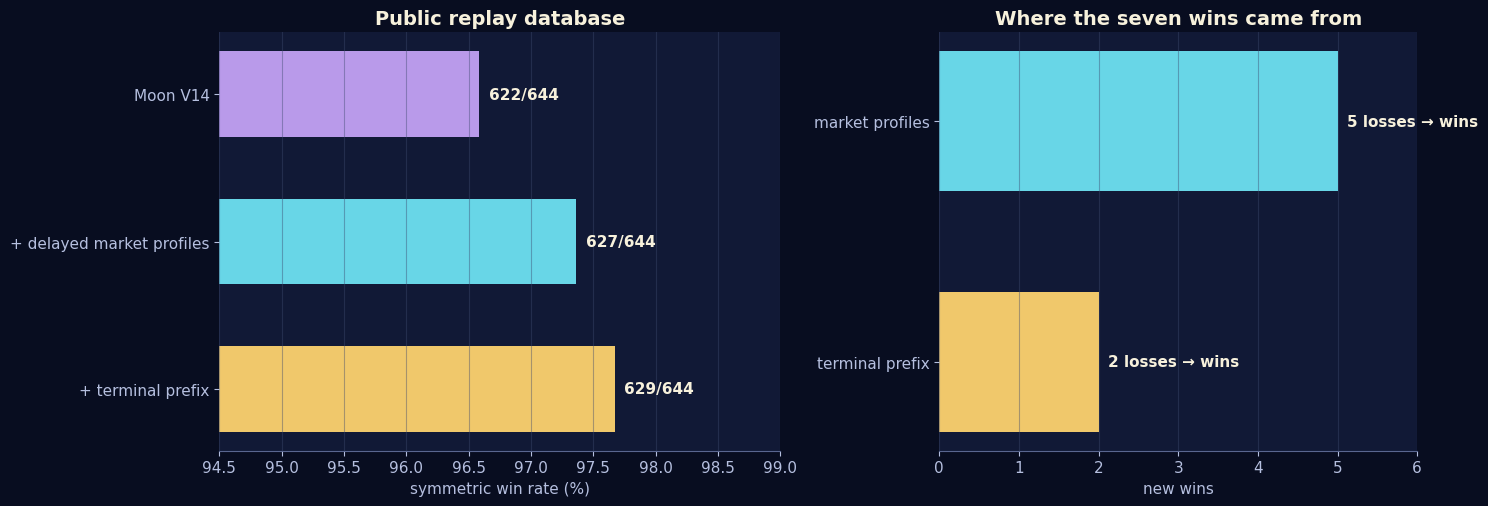

In [2]:
progress=pd.DataFrame({
    "layer":["Moon V14","+ delayed market profiles","+ terminal prefix"],
    "wins":[622,627,629],"games":[644,644,644],
})
progress["new wins"]=progress.wins.diff().fillna(progress.wins)
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(15,5.2),gridspec_kw={"width_ratios":[1.08,.92]})
b=ax0.barh(progress.layer,100*progress.wins/progress.games,color=[VIOLET,RAIN,MOON],height=.58)
ax0.bar_label(b,labels=[f"{w}/644" for w in progress.wins],padding=7,color=INK,weight="bold")
ax0.set_xlim(94.5,99); ax0.invert_yaxis(); ax0.set(title="Public replay database",xlabel="symmetric win rate (%)")
ax0.grid(axis="x"); ax0.spines[["top","right","left"]].set_visible(False)
increments=pd.DataFrame({"repair":["market profiles","terminal prefix"],"wins":[5,2]})
b=ax1.barh(increments.repair,increments.wins,color=[RAIN,MOON],height=.58)
ax1.bar_label(b,labels=["5 losses → wins","2 losses → wins"],padding=7,color=INK,weight="bold")
ax1.set_xlim(0,6); ax1.invert_yaxis(); ax1.set(title="Where the seven wins came from",xlabel="new wins")
ax1.grid(axis="x"); ax1.spines[["top","right","left"]].set_visible(False)
plt.tight_layout(); plt.show()

## Wait until the economy is observable

A two-shop rule was tempting and wrong. The same first pair appears in unrelated games, so early routing turned two safe broad-panel wins into losses. Waiting until step 288 reveals four shops and enough economic history to separate a close mirror from a merely similar scenario.

No opponent name, seed, episode id, or hidden state enters the live decision. The router reads only the first four unlocked shops and the absolute money gap already present in the observation.

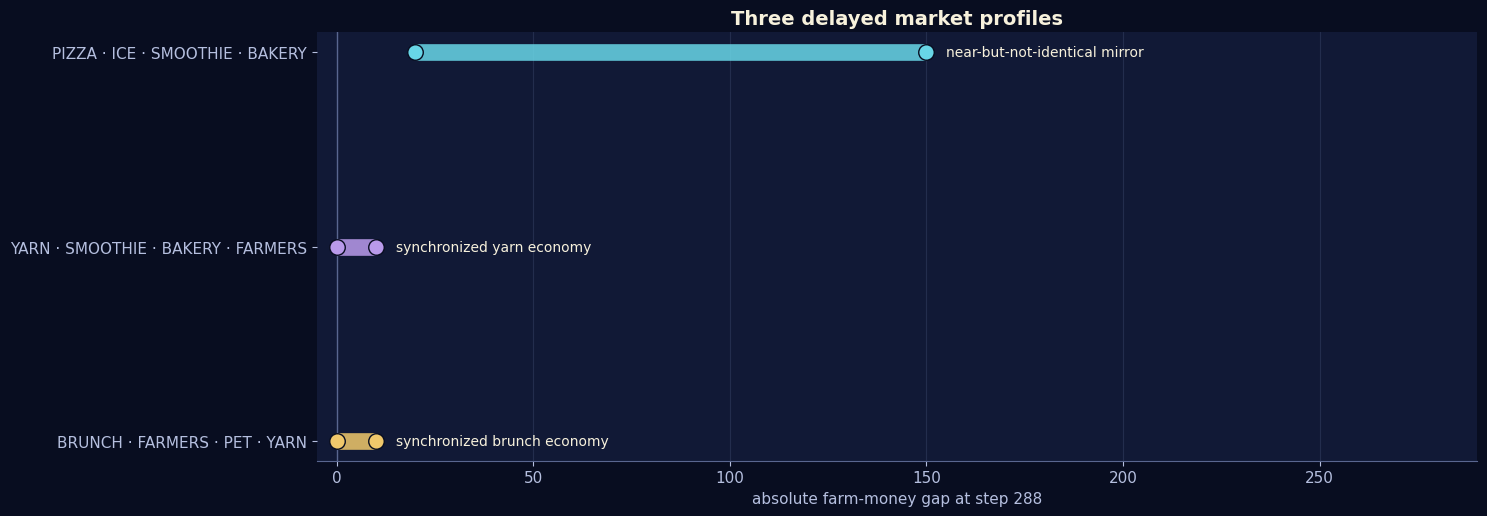

In [3]:
profiles=pd.DataFrame({
    "profile":["PIZZA · ICE · SMOOTHIE · BAKERY","YARN · SMOOTHIE · BAKERY · FARMERS","BRUNCH · FARMERS · PET · YARN"],
    "gap low":[20,0,0],"gap high":[150,10,10],
    "role":["near-but-not-identical mirror","synchronized yarn economy","synchronized brunch economy"],
})
fig,ax=plt.subplots(figsize=(15,5.3))
y=np.arange(len(profiles))
colors=[RAIN,VIOLET,MOON]
for i,row in profiles.iterrows():
    ax.hlines(i,row["gap low"],row["gap high"],color=colors[i],lw=12,alpha=.86)
    ax.scatter([row["gap low"],row["gap high"]],[i,i],s=125,color=colors[i],edgecolor=NAVY,zorder=3)
    ax.text(row["gap high"]+5,i,row.role,va="center",color=INK,fontsize=10)
ax.set_yticks(y,profiles.profile); ax.invert_yaxis(); ax.set_xlim(-5,290)
ax.axvline(0,color="#59668f",lw=1); ax.set(title="Three delayed market profiles",xlabel="absolute farm-money gap at step 288")
ax.grid(axis="x"); ax.spines[["top","right","left"]].set_visible(False); plt.tight_layout(); plt.show()

## Seven exact losses cross zero

The delayed market branch converts Carlos once, J.Mubasshir twice, and Somewhere twice. The terminal prefix converts the same Somewhere edge in both seats. These are matched before/after replays: identical opponent tape, seed, and seat.

Two already-safe Carlos games become about two thousand coins closer, but remain wins at +1,597 and +2,007. That bounded cost is preserved in the audit instead of being described as “no change.”

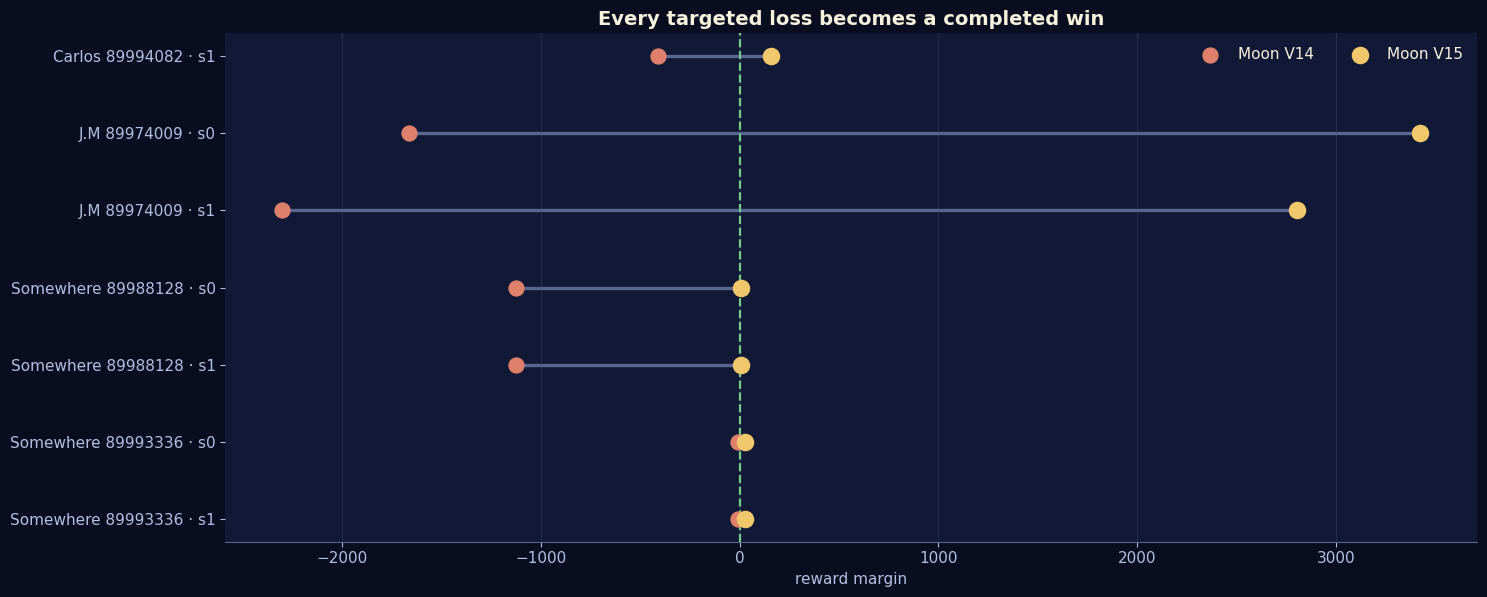

In [4]:
flips=pd.DataFrame({
    "game":["Carlos 89994082 · s1","J.M 89974009 · s0","J.M 89974009 · s1","Somewhere 89988128 · s0","Somewhere 89988128 · s1","Somewhere 89993336 · s0","Somewhere 89993336 · s1"],
    "V14":[-410,-1665,-2301,-1124,-1124,-6,-6],
    "V15":[158,3423,2803,6,6,25,25],
})
fig,ax=plt.subplots(figsize=(15,6.1))
y=np.arange(len(flips))
for i,row in flips.iterrows():
    ax.plot([row.V14,row.V15],[i,i],color="#59668f",lw=2.4,zorder=1)
ax.scatter(flips.V14,y,s=115,color=CLAY,label="Moon V14",zorder=3)
ax.scatter(flips.V15,y,s=135,color=MOON,label="Moon V15",zorder=3)
ax.axvline(0,color=GREEN,lw=1.6,ls="--")
ax.set_yticks(y,flips.game); ax.invert_yaxis(); ax.set(title="Every targeted loss becomes a completed win",xlabel="reward margin")
ax.legend(frameon=False,ncol=2); ax.grid(axis="x"); ax.spines[["top","right","left"]].set_visible(False)
plt.tight_layout(); plt.show()

## The rejected routers matter

The first conservative composition passed its tiny target set but lost two current-frontier games. Turning the brunch route off unconditionally restored those games and broke Carlos. A money-gap latch fixed Carlos and still collided with a Pizza–Ice broad scenario. Only the delayed four-shop profiles reproduced every V14 result outside the target database.

This is why a perfect repair screen is not a promotion gate.

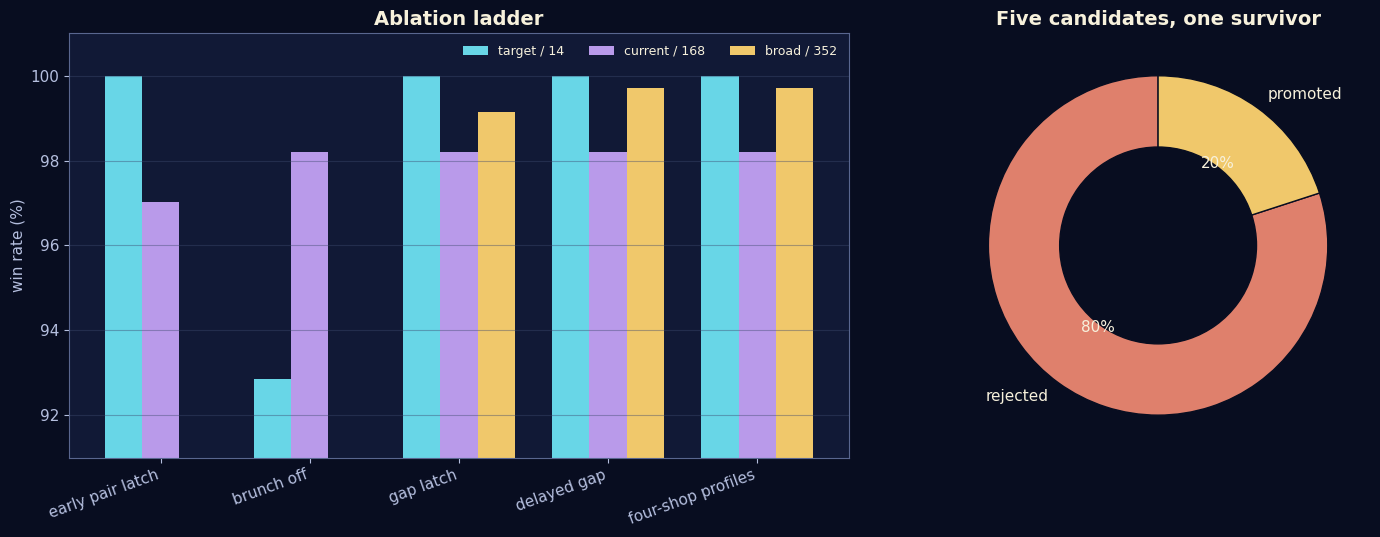

In [5]:
search=pd.DataFrame({
    "candidate":["early pair latch","brunch off","gap latch","delayed gap","four-shop profiles"],
    "target wins":[14,13,14,14,14],
    "current wins":[163,165,165,165,165],
    "broad wins":[np.nan,np.nan,349,351,351],
    "promoted":[False,False,False,False,True],
})
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(15,5.5),gridspec_kw={"width_ratios":[1.1,.9]})
x=np.arange(len(search)); w=.25
ax0.bar(x-w,100*search["target wins"]/14,w,label="target / 14",color=RAIN)
ax0.bar(x,100*search["current wins"]/168,w,label="current / 168",color=VIOLET)
ax0.bar(x+w,100*search["broad wins"]/352,w,label="broad / 352",color=MOON)
ax0.set_xticks(x,search.candidate,rotation=20,ha="right"); ax0.set_ylim(91,101)
ax0.set(title="Ablation ladder",ylabel="win rate (%)"); ax0.legend(frameon=False,ncol=3,fontsize=9); ax0.grid(axis="y")
outcomes=pd.DataFrame({"result":["rejected","promoted"],"count":[4,1]})
ax1.pie(outcomes["count"],labels=outcomes.result,colors=[CLAY,MOON],startangle=90,autopct="%1.0f%%",wedgeprops={"width":.42,"edgecolor":NAVY})
ax1.set(title="Five candidates, one survivor")
plt.tight_layout(); plt.show()

## Every remaining loss was replayed again

V15 leaves fifteen losses in the 644-game database. Seven contain at least one scheduled action executed on a currently visible weed. The other eight are terminal or stochastic edges under 500 coins, often with identical farms and empty inventories at the finish.

The distinction is causal: a weed collision needs a schedule-preserving transaction; a terminal edge needs ordering or valuation. Treating both with one global splice is exactly how regressions enter.

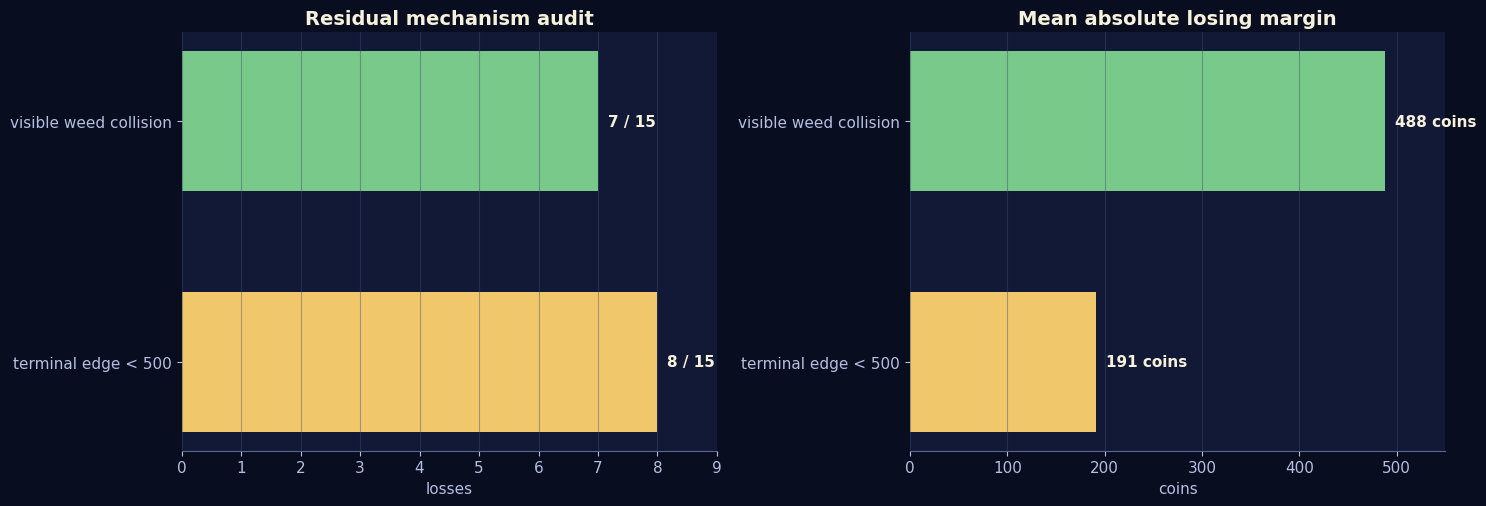

In [6]:
residual=pd.DataFrame({
    "mechanism":["visible weed collision","terminal edge < 500"],
    "games":[7,8],"mean magnitude":[488,191],
})
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(15,5.2))
b=ax0.barh(residual.mechanism,residual.games,color=[GREEN,MOON],height=.58)
ax0.bar_label(b,labels=["7 / 15","8 / 15"],padding=7,color=INK,weight="bold")
ax0.set_xlim(0,9); ax0.invert_yaxis(); ax0.set(title="Residual mechanism audit",xlabel="losses")
ax0.grid(axis="x"); ax0.spines[["top","right","left"]].set_visible(False)
b=ax1.barh(residual.mechanism,residual["mean magnitude"],color=[GREEN,MOON],height=.58)
ax1.bar_label(b,labels=["488 coins","191 coins"],padding=7,color=INK,weight="bold")
ax1.set_xlim(0,550); ax1.invert_yaxis(); ax1.set(title="Mean absolute losing margin",xlabel="coins")
ax1.grid(axis="x"); ax1.spines[["top","right","left"]].set_visible(False)
plt.tight_layout(); plt.show()

## Promotion means surviving unrelated games

The target set is 14/14. The candidate then reproduces Moon V14 exactly across 168 current-frontier games, 288 historical-seed games, and 352 broad-policy games: all 808 margins are byte-for-byte equivalent as numbers. The full public database rises to 629/644 with zero win-to-loss regressions.

These are local simulator and public-replay results, not a public-score estimate.

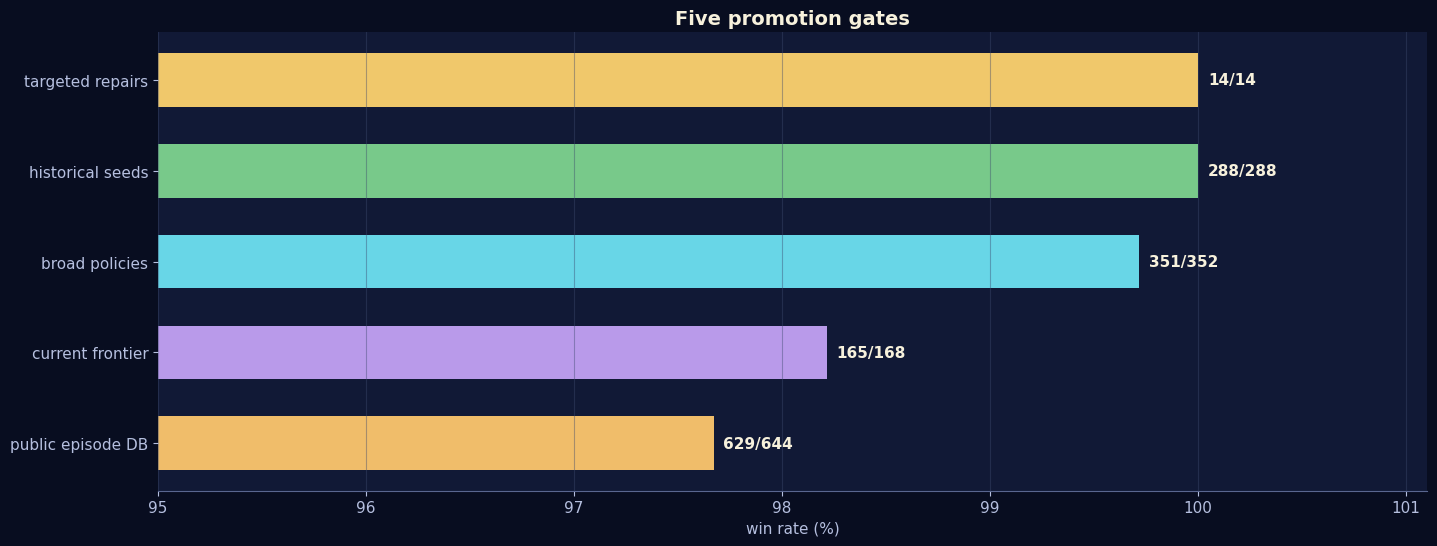

In [7]:
gates=pd.DataFrame({
    "gate":["targeted repairs","historical seeds","broad policies","current frontier","public episode DB"],
    "wins":[14,288,351,165,629],"games":[14,288,352,168,644],
})
gates["rate"]=100*gates.wins/gates.games
fig,ax=plt.subplots(figsize=(14.5,5.6))
colors=[MOON,GREEN,RAIN,VIOLET,"#f0bd6a"]
b=ax.barh(gates.gate,gates.rate,color=colors,height=.59)
ax.bar_label(b,labels=[f"{w}/{g}" for w,g in zip(gates.wins,gates.games)],padding=7,color=INK,weight="bold")
ax.set_xlim(95,101.1); ax.invert_yaxis(); ax.set(title="Five promotion gates",xlabel="win rate (%)")
ax.grid(axis="x"); ax.spines[["top","right","left"]].set_visible(False); plt.tight_layout(); plt.show()

## Non-interference is measured, not assumed

Across the three unrelated panels, every one of 808 margins is unchanged. In the 644-game database, 632 rows are unchanged, ten improve, and two safe Carlos wins become closer. That shape is the point of delaying the router: the counterfactual policy should remain dormant almost everywhere.

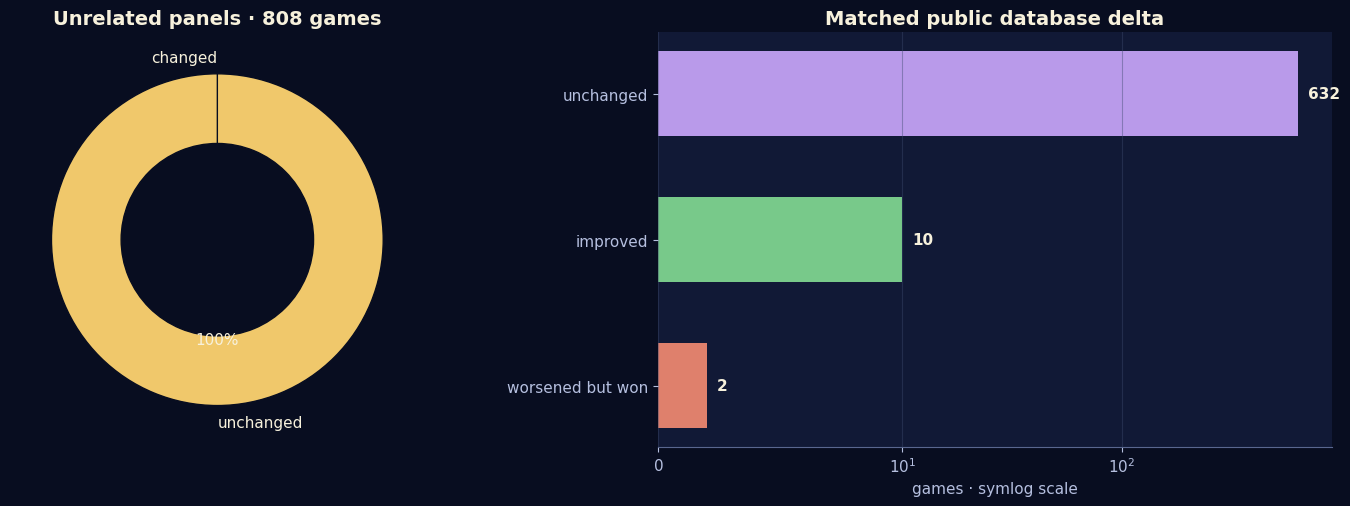

In [8]:
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(15,5.2))
ax0.pie([808,0],labels=["unchanged","changed"],colors=[MOON,CLAY],startangle=90,autopct=lambda p:f"{p:.0f}%" if p else "",wedgeprops={"width":.42,"edgecolor":NAVY})
ax0.set(title="Unrelated panels · 808 games")
db=pd.DataFrame({"outcome":["unchanged","improved","worsened but won"],"games":[632,10,2]})
b=ax1.barh(db.outcome,db.games,color=[VIOLET,GREEN,CLAY],height=.58)
ax1.bar_label(b,padding=7,color=INK,weight="bold"); ax1.set_xscale("symlog",linthresh=10)
ax1.set_xlim(0,900); ax1.invert_yaxis(); ax1.set(title="Matched public database delta",xlabel="games · symlog scale")
ax1.grid(axis="x"); ax1.spines[["top","right","left"]].set_visible(False)
plt.tight_layout(); plt.show()

## Keep the fifteen losses visible

The largest unresolved cases are late weed failures at −1,070, −816, and −796. The closest is −14. Seven of the fifteen already expose the crop previously planted on the failed tile, which suggests the next repair can be state based; however, the first remembered-crop replay ablation converted none and lowered mean margin, so it is not included here.

A loss atlas is more useful than a claim of perfection: it shows exactly where the next falsification work belongs.

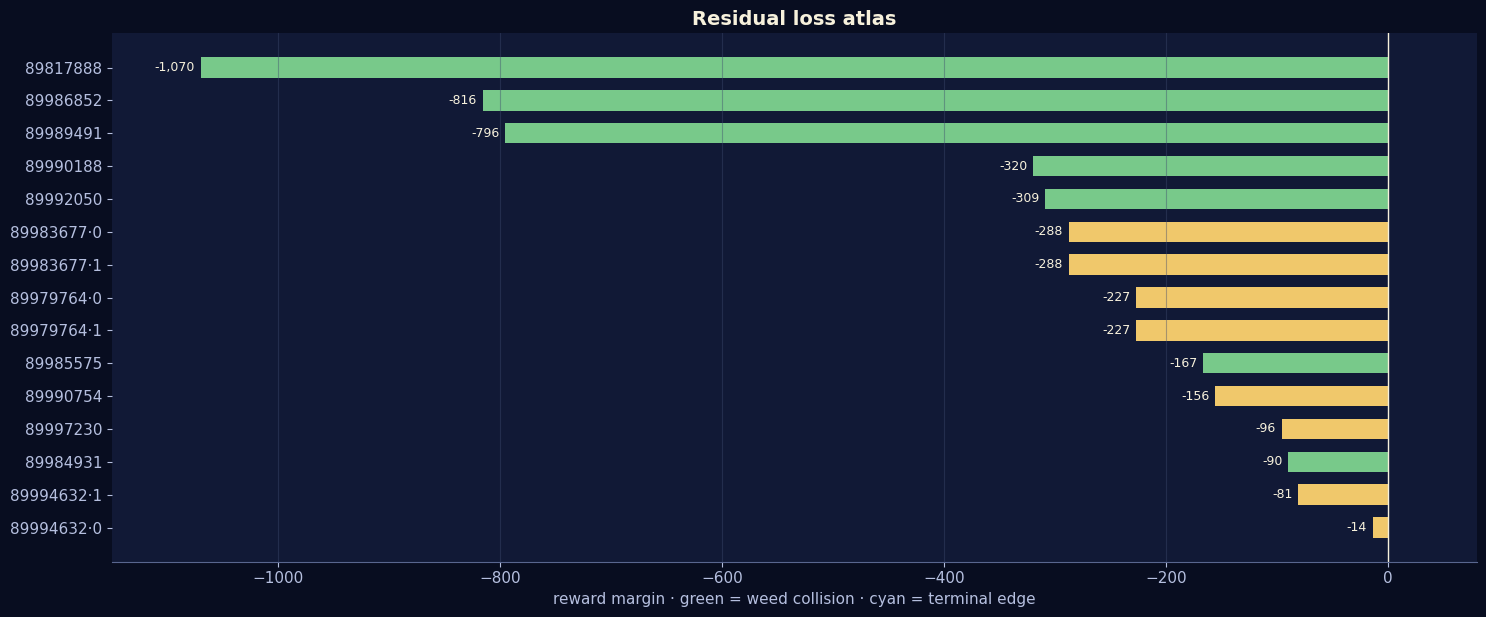

In [9]:
losses=pd.DataFrame({
    "episode":["89817888","89986852","89989491","89990188","89992050","89983677·0","89983677·1","89979764·0","89979764·1","89985575","89990754","89997230","89984931","89994632·1","89994632·0"],
    "margin":[-1070,-816,-796,-320,-309,-288,-288,-227,-227,-167,-156,-96,-90,-81,-14],
    "mechanism":["weed","weed","weed","weed","weed","terminal","terminal","terminal","terminal","weed","terminal","terminal","weed","terminal","terminal"],
})
colors=losses.mechanism.map({"weed":GREEN,"terminal":MOON})
fig,ax=plt.subplots(figsize=(15,6.3))
y=np.arange(len(losses)); b=ax.barh(y,losses.margin,color=colors,height=.62)
ax.bar_label(b,labels=[f"{x:+,}" for x in losses.margin],padding=4,color=INK,fontsize=9)
ax.set_yticks(y,losses.episode); ax.invert_yaxis(); ax.set_xlim(-1150,80)
ax.axvline(0,color=INK,lw=1); ax.set(title="Residual loss atlas",xlabel="reward margin · green = weed collision · cyan = terminal edge")
ax.grid(axis="x"); ax.spines[["top","right","left"]].set_visible(False); plt.tight_layout(); plt.show()

## Write the exact frozen agent

The artifact cell stops unless the embedded source reproduces the pre-promotion digest byte for byte. The SHA-256 begins `868e095c`.

In [10]:
AGENT_SOURCE = '"""Fixed public Subin An policy from episode 89945750, seat 1."""\nimport copy\n\nTRACE_ACTIONS = [{\'farmer\': [\'PASS\'], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6], [\'BUY_SEED\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'COW\', 1], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'PLACE\', \'COW\'], \'hands\': [[\'BUILD_PASTURE\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'BUILD_PASTURE\'], [\'BUILD_PASTURE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PICKUP\', \'COW\', 2], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'SHEEP\', 1], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PLACE\', \'COW\'], [\'WATER\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'PLACE\', \'SHEEP\'], \'hands\': [[\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'FEED\'], [\'PLANT\', \'MELON\'], [\'PLANT\', \'MELON\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'PLACE\', \'COW\'], [\'PLANT\', \'MELON\'], [\'PLANT\', \'MELON\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'CARE\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'MELON\'], [\'EAST\'], [\'PLANT\', \'WHEAT\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 4]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 7]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'CARROT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'MELON\', 3], [\'BUY_SEED\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'HARVEST\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'WHEAT\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_SEED\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'DROP\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 31], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'BUILD_PASTURE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'COW\', 1], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'SHEEP\', 1], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'PLACE\', \'SHEEP\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'CARE\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'DROP\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'DROP\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'WATER\']], \'market\': [[\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PICKUP\', \'COW\', 1], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'BUY_LAND\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'COW\', 1], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 4], [\'BUY_SEED\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 10]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'MELON\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'WEST\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'DROP\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'CARE\'], [\'WEST\'], [\'PICKUP\', \'SHEEP\', 1], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'PLACE\', \'SHEEP\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'PICKUP\', \'SHEEP\', 1], [\'FEED\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'BUILD_PASTURE\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'PLACE\', \'SHEEP\'], [\'PICKUP\', \'SHEEP\', 2], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'FEED\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'PLACE\', \'SHEEP\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'FEED\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'CARE\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'PLACE\', \'SHEEP\'], [\'EAST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'CARE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PLANT\', \'STRAWBERRY\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'PICKUP\', \'FERTILIZER\', 1], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'PICKUP\', \'WHEAT\', 1], [\'NORTH\'], [\'HARVEST\'], [\'DIG\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'DIG\'], [\'FERTILIZE\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'DIG\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'COW\', 1], \'hands\': [[\'WATER\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'DROP\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 9]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PLACE\', \'COW\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'PASS\'], [\'WEST\'], [\'HARVEST\'], [\'DROP\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 16], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_LAND\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'COW\', 1], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'PLANT\', \'STRAWBERRY\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'BUILD_PASTURE\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 11], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'PICKUP\', \'COW\', 1], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'MELON\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 27], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'COW\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'PLACE\', \'COW\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'FEED\'], [\'PLANT\', \'MELON\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'DROP\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 22], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 49]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\']], \'market\': [[\'SELL\', \'WHEAT\', 38], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 56]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'DROP\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 35]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'FEED\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 12]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MELON\', 12], [\'SELL\', \'WHEAT\', 22], [\'SELL\', \'TOMATO\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'PLANT\', \'MELON\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 20]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'DROP\']], \'market\': [[\'SELL\', \'WOOL\', 5], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'FERTILIZE\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'FERTILIZE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'CARE\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'DROP\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'DIG\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'MELON\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'DROP\'], [\'DIG\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 8]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PLANT\', \'MELON\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 14]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'CARE\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 13], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\']], \'market\': [[\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'EAST\'], [\'CARE\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WOOL\', 7]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'DROP\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'DROP\'], [\'HARVEST\'], [\'DIG\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 6]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'WEST\'], [\'DROP\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'MELON\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PASS\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 7]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 5], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'MELON\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 7], [\'SELL\', \'FERTILIZER\', 20], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'FEED\'], [\'HARVEST\'], [\'FEED\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'DIG\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 22]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'PASS\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'MILK\', 28], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'FEED\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 14]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'DIG\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'PLANT\', \'WHEAT\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'DIG\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 4], [\'SELL\', \'MILK\', 5], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'HARVEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 5]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 5]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'WATER\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 5], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'DROP\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'DROP\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 4], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'DROP\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'DIG\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'WHEAT\'], [\'PASS\'], [\'FERTILIZE\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'DROP\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'PASS\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 8]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 8]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'FEED\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'SELL\', \'MILK\', 4]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'FEED\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 17], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'CARROT\', 2], [\'SELL\', \'MILK\', 5], [\'SELL\', \'WOOL\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'MILK\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WOOL\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'FEED\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'SELL\', \'WOOL\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'MILK\', 6]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WOOL\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 10]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 10]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'DROP\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 12]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 15]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'SOUTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 20]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'SELL\', \'CARROT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 19]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 7]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'DROP\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 7]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'DROP\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'PASS\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MELON\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'MELON\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'MELON\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'FERTILIZE\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'DIG\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 13]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'EAST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'DIG\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FERTILIZE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 2], [\'SELL\', \'WHEAT\', 14]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'DROP\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MELON\', 10], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'SELL\', \'CARROT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'EAST\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FERTILIZE\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 24]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'WATER\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'MILK\', 19]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 7]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\']], \'market\': [[\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 24]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 44]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'FERTILIZE\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'DROP\'], [\'FERTILIZE\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'DROP\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 8], [\'SELL\', \'WOOL\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 12]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'PASS\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WOOL\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2]], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'STRAWBERRY\', 13]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'HARVEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'CARE\'], [\'WEST\'], [\'HARVEST\'], [\'FEED\'], [\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 1]]}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'DROP\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'WHEAT\', 16], [\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MELON\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'DROP\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 1], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 29], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 8], [\'SELL\', \'STRAWBERRY\', 35], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'MELON\', 7]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'CARE\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'WATER\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 6]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'DROP\'], [\'HARVEST\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WATER\'], [\'DIG\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'DIG\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'DIG\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'DROP\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'DIG\'], [\'EAST\'], [\'HARVEST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 6]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'DIG\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 15]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'FEED\'], [\'WATER\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 6]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'WEST\'], [\'DIG\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 9]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 9]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'DIG\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 9], [\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'EGG\', 8]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 14], [\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'DIG\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'DIG\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 8], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'FERTILIZER\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 7], [\'PICKUP\', \'FERTILIZER\', 3], [\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WOOL\', 1], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'WHEAT\', 30]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'CARE\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'CARE\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'CARE\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'STRAWBERRY\', 20]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 15]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 15], [\'SELL\', \'STRAWBERRY\', 20]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'DIG\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'DIG\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'SELL\', \'MILK\', 30], [\'SELL\', \'STRAWBERRY\', 20]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'DIG\'], [\'WEST\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 5], [\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'FERTILIZE\'], [\'PLANT\', \'WHEAT\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'DIG\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 8], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'FERTILIZER\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 7], [\'PICKUP\', \'FERTILIZER\', 4], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'SELL\', \'FERTILIZER\', 16], [\'SELL\', \'MELON\', 6], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'CARE\'], [\'EAST\']], \'market\': [[\'SELL\', \'WOOL\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WOOL\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 10], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'PASS\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'SELL\', \'STRAWBERRY\', 9]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 8]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'FERTILIZE\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'MILK\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'FERTILIZE\'], [\'PASS\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'MILK\', 15]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'FERTILIZE\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 8], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'FERTILIZER\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 7], [\'PICKUP\', \'FERTILIZER\', 4], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'MILK\', 4], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'SELL\', \'MILK\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 8]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 29], [\'BUY_PRODUCT\', \'WHEAT\', 12]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 12]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'FERTILIZE\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 12], [\'SELL\', \'MILK\', 1], [\'SELL\', \'STRAWBERRY\', 23]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 14]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 32], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FERTILIZE\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'FERTILIZER\', 9], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MELON\', 12], [\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 20], [\'SELL\', \'WHEAT\', 23]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 22]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 11]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 6]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MELON\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MELON\', 8], [\'SELL\', \'WOOL\', 12], [\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 3], [\'SELL\', \'MILK\', 9], [\'SELL\', \'WHEAT\', 36], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 1]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'DROP\'], [\'NORTH\'], [\'DROP\'], [\'DROP\'], [\'SOUTH\'], [\'DROP\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MILK\', 12], [\'SELL\', \'FERTILIZER\', 10]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'WHEAT\', 40], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'MELON\', 3], [\'SELL\', \'MILK\', 3], [\'SELL\', \'MELON\', 5], [\'SELL\', \'WHEAT\', 20]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'MELON\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLACE\', \'WOOL\', 4], [\'PLACE\', \'MILK\', 3], [\'PASS\'], [\'PLACE\', \'WOOL\', 4], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'WOOL\', 4], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLACE\', \'WHEAT\', 5], [\'PLACE\', \'STRAWBERRY\', 3], [\'PASS\'], [\'PLACE\', \'MILK\', 3], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'WHEAT\', 5], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WHEAT\', 10], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLACE\', \'FERTILIZER\', 1], [\'PLACE\', \'WHEAT\', 7], [\'PASS\'], [\'PLACE\', \'WHEAT\', 3], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'FERTILIZER\', 1], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'FERTILIZER\', 2], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'FERTILIZER\', 2], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}]\n\n\ndef _SUBIN_WEED_BASE(obs, config=None):\n    step = min(int(obs.get("step", 0) or 0), len(TRACE_ACTIONS) - 1)\n    return copy.deepcopy(TRACE_ACTIONS[step])\n\n\n_SUBIN_WEED_REPAIR = False\n\n\ndef _subin_weed_tile(farm, position):\n    try:\n        x, y = int(position[0]), int(position[1])\n        return (farm.get("tiles", []) or [])[y][x]\n    except (IndexError, TypeError, ValueError):\n        return "LOCKED"\n\n\ndef _SUBIN_WEED_TERMINAL_BASE(obs, config=None):\n    global _SUBIN_WEED_REPAIR\n    action = copy.deepcopy(_SUBIN_WEED_BASE(obs, config))\n    step = int(obs.get("step", 0) or 0)\n    if step == 0:\n        _SUBIN_WEED_REPAIR = False\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    if player not in (0, 1) or len(farms) != 2:\n        return action\n    farm = farms[player] or {}\n    hands = farm.get("hands", []) or []\n    hand_actions = list(action.get("hands", []) or [])\n    if len(hands) <= 7 or len(hand_actions) <= 7:\n        return action\n    tile = _subin_weed_tile(farm, (5, 4))\n    if (\n        step == 198 and tuple(hands[7]) == (5, 4)\n        and isinstance(tile, dict) and tile.get("kind") == "WEED"\n    ):\n        _SUBIN_WEED_REPAIR = True\n        hand_actions[7] = ["DIG"]\n        action["hands"] = hand_actions\n        return action\n    if _SUBIN_WEED_REPAIR and step == 199:\n        if tuple(hands[7]) == (5, 4) and tile is None:\n            hand_actions[7] = ["BUILD_PASTURE"]\n            action["hands"] = hand_actions\n        else:\n            _SUBIN_WEED_REPAIR = False\n        return action\n    if _SUBIN_WEED_REPAIR and 200 <= step <= 208:\n        previous = TRACE_ACTIONS[step - 1].get("hands", []) or []\n        if len(previous) > 7:\n            hand_actions[7] = copy.deepcopy(previous[7])\n            action["hands"] = hand_actions\n    elif step >= 209:\n        _SUBIN_WEED_REPAIR = False\n    return action\n\n\n_SUBIN_TERMINAL_PRODUCTS = {\n    "WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON",\n    "EGG", "MILK", "WOOL", "FERTILIZER",\n}\n\n\ndef _subin_terminal_choice(inventory, prices):\n    choices = [\n        (int(prices.get(item, 0) or 0) * int(quantity or 0),\n         int(prices.get(item, 0) or 0), int(quantity or 0), item)\n        for item, quantity in (inventory or {}).items()\n        if item in _SUBIN_TERMINAL_PRODUCTS and int(quantity or 0) > 0\n    ]\n    return max(choices, default=None)\n\n\ndef _SUBIN_MULTI_WEED_BASE(obs, config=None):\n    action = copy.deepcopy(_SUBIN_WEED_TERMINAL_BASE(obs, config))\n    step = int(obs.get("step", 0) or 0)\n    if step < 716:\n        return action\n    private = obs.get("private", {}) or {}\n    inventories = private.get("inventories", []) or []\n    shed = private.get("shed", {}) or {}\n    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    farm = farms[player] if 0 <= player < len(farms) else {}\n    hand_count = len(farm.get("hands", []) or [])\n    placed = {}\n    farmer_choice = _subin_terminal_choice(\n        inventories[0] if inventories else {}, prices\n    )\n    action["farmer"] = ["PASS"]\n    if farmer_choice is not None:\n        _, _, quantity, item = farmer_choice\n        action["farmer"] = ["PLACE", item, quantity]\n        placed[item] = placed.get(item, 0) + quantity\n    hand_actions = []\n    for index in range(hand_count):\n        inventory = inventories[index + 1] if index + 1 < len(inventories) else {}\n        choice = _subin_terminal_choice(inventory, prices)\n        if choice is None:\n            hand_actions.append(["PASS"])\n            continue\n        _, _, quantity, item = choice\n        hand_actions.append(["PLACE", item, quantity])\n        placed[item] = placed.get(item, 0) + quantity\n    action["hands"] = hand_actions\n    sale_totals = {\n        item: int(shed.get(item, 0) or 0) + int(placed.get(item, 0) or 0)\n        for item in _SUBIN_TERMINAL_PRODUCTS\n        if int(shed.get(item, 0) or 0) + int(placed.get(item, 0) or 0) > 0\n    }\n    ordered = sorted(\n        sale_totals,\n        key=lambda item: (\n            int(prices.get(item, 0) or 0) * sale_totals[item],\n            int(prices.get(item, 0) or 0), sale_totals[item], item,\n        ),\n        reverse=True,\n    )\n    action["market"] = [["SELL", item, sale_totals[item]] for item in ordered[:10]]\n    return action\n\n\n_SUBIN_MULTI_WEED_WINDOWS = {\n    (125, 3): 128,\n    (126, 4): 143,\n    (203, 5): 213,\n    (233, 7): 237,\n}\n_SUBIN_MULTI_WEED_ACTIVE = {}\n\n\ndef _subin_multi_weed_tile(farm, position):\n    try:\n        x, y = int(position[0]), int(position[1])\n        return (farm.get("tiles", []) or [])[y][x]\n    except (IndexError, TypeError, ValueError):\n        return "LOCKED"\n\n\ndef _SUBIN_MULTI_WEED_TOP_BASE(obs, config=None):\n    global _SUBIN_MULTI_WEED_ACTIVE\n    action = copy.deepcopy(_SUBIN_MULTI_WEED_BASE(obs, config))\n    step = int(obs.get("step", 0) or 0)\n    if step == 0:\n        _SUBIN_MULTI_WEED_ACTIVE = {}\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    if player not in (0, 1) or len(farms) != 2:\n        return action\n    farm = farms[player] or {}\n    hands = farm.get("hands", []) or []\n    hand_actions = list(action.get("hands", []) or [])\n\n    for index, (start, end) in list(_SUBIN_MULTI_WEED_ACTIVE.items()):\n        if index >= len(hand_actions):\n            continue\n        if step == start + 1:\n            hand_actions[index] = ["BUILD_PASTURE"]\n        elif start + 2 <= step <= end:\n            previous = TRACE_ACTIONS[step - 1].get("hands", []) or []\n            if index < len(previous):\n                hand_actions[index] = copy.deepcopy(previous[index])\n        if step >= end:\n            _SUBIN_MULTI_WEED_ACTIVE.pop(index, None)\n\n    for (start, index), end in _SUBIN_MULTI_WEED_WINDOWS.items():\n        if step != start or index in _SUBIN_MULTI_WEED_ACTIVE:\n            continue\n        if index >= len(hands) or index >= len(hand_actions):\n            continue\n        tile = _subin_multi_weed_tile(farm, hands[index])\n        if (\n            hand_actions[index] == ["BUILD_PASTURE"]\n            and isinstance(tile, dict) and tile.get("kind") == "WEED"\n        ):\n            _SUBIN_MULTI_WEED_ACTIVE[index] = (start, end)\n            hand_actions[index] = ["DIG"]\n    action["hands"] = hand_actions\n    return action\n\n_TOP_MARKET = [[[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6], [\'BUY_SEED\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WHEAT\', 7]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 1]], [], [], [], [], [], [], [[\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 5]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 8]], [], [[\'SELL\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'FERTILIZER\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [[\'BUY_SEED\', \'MELON\', 3], [\'BUY_SEED\', \'WHEAT\', 3]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 31], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [[\'SELL\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'BUY_LAND\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 4], [\'BUY_SEED\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 10]], [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 5]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3]], [[\'SELL\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 9]], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [], [], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'MELON\', 6]], [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'SELL\', \'MELON\', 16], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'BUY_LAND\']], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MELON\', 11], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_SEED\', \'MELON\', 2]], [[\'SELL\', \'MELON\', 27], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [], [], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 22], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'MILK\', 12]], [[\'SELL\', \'MILK\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 49]], [[\'SELL\', \'WHEAT\', 38], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'WHEAT\', 56]], [], [[\'SELL\', \'MILK\', 9]], [[\'SELL\', \'WHEAT\', 35], [\'SELL\', \'MILK\', 6]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'FERTILIZER\', 12]], [[\'SELL\', \'MELON\', 12], [\'SELL\', \'WHEAT\', 22], [\'SELL\', \'TOMATO\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'WOOL\', 5], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'SELL\', \'FERTILIZER\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 9]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 8], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'FERTILIZER\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'WHEAT\', 5], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 13], [\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'MILK\', 4]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 6]], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'MELON\', 3]], [], [], [], [[\'SELL\', \'MELON\', 5], [\'SELL\', \'MELON\', 1], [\'SELL\', \'WOOL\', 7]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'MELON\', 7], [\'SELL\', \'FERTILIZER\', 20], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MELON\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'WOOL\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 22]], [], [], [], [], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MILK\', 28], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 14]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 4], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'MILK\', 4], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 15]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'SELL\', \'STRAWBERRY\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 5], [\'SELL\', \'WHEAT\', 15], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MELON\', 4], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'FERTILIZER\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [], [[\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'MILK\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 3], [\'SELL\', \'MILK\', 3], [\'SELL\', \'MILK\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'STRAWBERRY\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'WOOL\', 2], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'WOOL\', 2], [\'SELL\', \'MILK\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 17], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'CARROT\', 2]], [[\'SELL\', \'MILK\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MILK\', 6], [\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'FERTILIZER\', 2]], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 6]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'WOOL\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'STRAWBERRY\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'STRAWBERRY\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 10], [\'SELL\', \'MILK\', 9]], [[\'SELL\', \'STRAWBERRY\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 12]], [], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 13]], [[\'SELL\', \'STRAWBERRY\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 20]], [], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'CARROT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'SELL\', \'WHEAT\', 19], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 7]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 4]], [[\'SELL\', \'MELON\', 2], [\'SELL\', \'STRAWBERRY\', 7]], [[\'SELL\', \'STRAWBERRY\', 4]], [], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 6]], [[\'SELL\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'STRAWBERRY\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'MELON\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 5]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 13]], [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 4]], [], [], [[\'SELL\', \'FERTILIZER\', 3]], [], [], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'WHEAT\', 14], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MELON\', 10], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 15]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'CARROT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 7]], [[\'SELL\', \'STRAWBERRY\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'MILK\', 19]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 7]], [[\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 24]], [[\'SELL\', \'WOOL\', 44], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 5], [\'SELL\', \'FERTILIZER\', 4]], [[\'SELL\', \'STRAWBERRY\', 6]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'WOOL\', 12]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 8], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 4], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'MILK\', 4]], [[\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 6]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'WHEAT\', 16], [\'SELL\', \'WOOL\', 3], [\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 3], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 12], [\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 27], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 11]], [[\'SELL\', \'STRAWBERRY\', 35], [\'SELL\', \'MELON\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 7], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 6]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 6], [\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'FERTILIZER\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 6], [\'SELL\', \'MILK\', 6], [\'SELL\', \'MILK\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 11]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [], [[\'SELL\', \'WOOL\', 9]], [[\'SELL\', \'WOOL\', 9], [\'SELL\', \'WOOL\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 6]], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'EGG\', 8], [\'SELL\', \'WOOL\', 3]], [[\'SELL\', \'WOOL\', 9], [\'SELL\', \'MILK\', 14], [\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 1]], [], [], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'MELON\', 6], [\'SELL\', \'WOOL\', 1], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'WHEAT\', 30]], [[\'SELL\', \'STRAWBERRY\', 20]], [[\'SELL\', \'WOOL\', 2]], [], [], [], [[\'SELL\', \'WOOL\', 12]], [], [[\'SELL\', \'MILK\', 15]], [], [], [], [[\'SELL\', \'MILK\', 30], [\'SELL\', \'STRAWBERRY\', 20]], [], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 1], [\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WHEAT\', 3]], [], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 16], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'MILK\', 9]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [], [[\'SELL\', \'MILK\', 10]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'SELL\', \'STRAWBERRY\', 5]], [[\'SELL\', \'STRAWBERRY\', 8], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 4]], [], [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 8]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'MILK\', 15]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'MILK\', 3], [\'SELL\', \'MILK\', 4], [\'SELL\', \'FERTILIZER\', 8], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'STRAWBERRY\', 9]], [[\'SELL\', \'FERTILIZER\', 5]], [], [[\'SELL\', \'MILK\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 29], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'SELL\', \'STRAWBERRY\', 3]], [], [], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MILK\', 12], [\'SELL\', \'STRAWBERRY\', 23], [\'SELL\', \'MILK\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 6]], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 14]], [], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 32], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'FERTILIZER\', 9], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'WOOL\', 18]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'MELON\', 1], [\'SELL\', \'MELON\', 8], [\'SELL\', \'MILK\', 11]], [[\'SELL\', \'MELON\', 1], [\'SELL\', \'WOOL\', 24], [\'SELL\', \'MILK\', 3]], [], [[\'SELL\', \'WHEAT\', 6]], [], [], [], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'WHEAT\', 36], [\'SELL\', \'MILK\', 9], [\'SELL\', \'MELON\', 3], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MILK\', 12], [\'SELL\', \'FERTILIZER\', 10]], [[\'SELL\', \'WHEAT\', 40], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'MELON\', 5], [\'SELL\', \'MELON\', 3], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'MELON\', 3]], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'WHEAT\', 20]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]]]\n_TOP_MARKET_CUTOFF = 680\n\n\ndef _SUBIN_CARLOS_ROUTER_BASE(obs, config=None):\n    action = copy.deepcopy(_SUBIN_MULTI_WEED_TOP_BASE(obs, config))\n    step = min(int(obs.get("step", 0) or 0), len(_TOP_MARKET) - 1)\n    if step < _TOP_MARKET_CUTOFF:\n        action["market"] = copy.deepcopy(_TOP_MARKET[step])\n    return action\n\n_CARLOS_ROUTER_SAVKO_MARKET = [[[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6], [\'BUY_SEED\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WHEAT\', 7]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 1]], [], [], [], [], [], [], [[\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 5]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 8]], [], [[\'SELL\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'FERTILIZER\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [[\'BUY_SEED\', \'MELON\', 3], [\'BUY_SEED\', \'WHEAT\', 3]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 31], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [[\'SELL\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'BUY_LAND\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 4], [\'BUY_SEED\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 10]], [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 5]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3]], [[\'SELL\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 9]], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [], [], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'MELON\', 6]], [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'SELL\', \'MELON\', 16], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'BUY_LAND\']], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MELON\', 11], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_SEED\', \'MELON\', 2]], [[\'SELL\', \'MELON\', 27], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [], [], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 22], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 9]], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 9]], [], [[\'SELL\', \'MILK\', 12]], [[\'SELL\', \'MILK\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 49]], [[\'SELL\', \'WHEAT\', 38], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'WHEAT\', 56]], [], [[\'SELL\', \'MILK\', 9]], [[\'SELL\', \'WHEAT\', 35], [\'SELL\', \'MILK\', 6]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'FERTILIZER\', 12]], [[\'SELL\', \'MELON\', 12], [\'SELL\', \'WHEAT\', 22], [\'SELL\', \'TOMATO\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'WOOL\', 5], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'SELL\', \'FERTILIZER\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 9]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 1]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 8], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'FERTILIZER\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'WHEAT\', 5], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'SELL\', \'MILK\', 3]], [], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 13], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 7], [\'SELL\', \'MILK\', 4]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 6]], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'MELON\', 3]], [], [], [], [[\'SELL\', \'WOOL\', 7]], [[\'SELL\', \'MELON\', 5], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'MELON\', 1]], [[\'SELL\', \'MELON\', 7], [\'SELL\', \'FERTILIZER\', 20], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'MELON\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 4]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'SELL\', \'MILK\', 9]], [[\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'WOOL\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 22]], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'FERTILIZER\', 3], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WOOL\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 9]], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MILK\', 28], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 14]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 4], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'MILK\', 4], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 15]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 5]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 5], [\'SELL\', \'WHEAT\', 15], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MELON\', 4], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WOOL\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [], [[\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14], [\'SELL\', \'STRAWBERRY\', 8]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'STRAWBERRY\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'SELL\', \'MILK\', 9]], [[\'SELL\', \'MILK\', 3]], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'STRAWBERRY\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 3]], [[\'SELL\', \'MILK\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 17], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'CARROT\', 2], [\'SELL\', \'WOOL\', 2], [\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 20], [\'SELL\', \'WOOL\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'MILK\', 6], [\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'FERTILIZER\', 2]], [], [], [[\'SELL\', \'WOOL\', 4]], [], [[\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'WOOL\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 1]], [[\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 11]], [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'STRAWBERRY\', 10], [\'SELL\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 9]], [[\'SELL\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'WHEAT\', 17], [\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'STRAWBERRY\', 10], [\'SELL\', \'MILK\', 9]], [[\'SELL\', \'STRAWBERRY\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 12]], [], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 9]], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 13], [\'SELL\', \'MILK\', 15]], [[\'SELL\', \'STRAWBERRY\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 20]], [], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'WHEAT\', 19], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 7]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 4]], [[\'SELL\', \'STRAWBERRY\', 7]], [[\'SELL\', \'STRAWBERRY\', 4]], [], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 6]], [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'MELON\', 2]], [], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'MELON\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'STRAWBERRY\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'MELON\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 13], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 4], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'MILK\', 1]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 3]], [], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 1]], [[\'SELL\', \'WHEAT\', 14], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MELON\', 10], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 15]], [[\'SELL\', \'CARROT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 7]], [[\'SELL\', \'STRAWBERRY\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 12]], [[\'SELL\', \'WOOL\', 24]], [[\'SELL\', \'MILK\', 12]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 19]], [[\'SELL\', \'FERTILIZER\', 8], [\'SELL\', \'WOOL\', 24], [\'BUY_PRODUCT\', \'WHEAT\', 7]], [[\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 24]], [[\'SELL\', \'WOOL\', 44], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 5], [\'SELL\', \'FERTILIZER\', 4]], [[\'SELL\', \'STRAWBERRY\', 6]], [[\'SELL\', \'FERTILIZER\', 8], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 12]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 8], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 13]], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'MELON\', 6]], [[\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 16], [\'SELL\', \'WOOL\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 12], [\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'MILK\', 12], [\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 29], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 11]], [[\'SELL\', \'STRAWBERRY\', 35], [\'SELL\', \'MELON\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 7], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 6]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'FERTILIZER\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 11]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'SELL\', \'MILK\', 6]], [[\'SELL\', \'MILK\', 15]], [[\'SELL\', \'MILK\', 6]], [[\'SELL\', \'MILK\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 6]], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 9]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WOOL\', 12]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 6], [\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'EGG\', 8]], [[\'SELL\', \'MILK\', 14], [\'SELL\', \'WOOL\', 9], [\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 1]], [], [], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WOOL\', 1], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'WHEAT\', 30]], [], [[\'SELL\', \'WOOL\', 2]], [], [[\'SELL\', \'STRAWBERRY\', 20]], [[\'SELL\', \'MILK\', 15]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WOOL\', 12]], [[\'SELL\', \'MILK\', 15]], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'STRAWBERRY\', 20]], [], [], [], [[\'SELL\', \'MILK\', 30], [\'SELL\', \'STRAWBERRY\', 20]], [], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 1], [\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WHEAT\', 3]], [], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 16], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 9]], [[\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 10]], [[\'SELL\', \'MILK\', 10], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 8]], [[\'SELL\', \'STRAWBERRY\', 4]], [], [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 8]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'MILK\', 15]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'MILK\', 4], [\'SELL\', \'FERTILIZER\', 8], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'MILK\', 8]], [], [[\'SELL\', \'FERTILIZER\', 5]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'WHEAT\', 29], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 12]], [], [], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MILK\', 12], [\'SELL\', \'STRAWBERRY\', 23], [\'SELL\', \'MILK\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 6]], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'WHEAT\', 3]], [], [[\'SELL\', \'WHEAT\', 32], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 14]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MELON\', 12], [\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'WHEAT\', 23], [\'SELL\', \'FERTILIZER\', 9], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9]], [[\'SELL\', \'WOOL\', 22]], [], [], [[\'SELL\', \'MILK\', 11]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'MILK\', 3]], [], [[\'SELL\', \'WHEAT\', 6]], [], [[\'SELL\', \'MELON\', 1]], [], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MELON\', 8], [\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'WHEAT\', 36], [\'SELL\', \'MELON\', 3], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MILK\', 12], [\'SELL\', \'FERTILIZER\', 10]], [[\'SELL\', \'WHEAT\', 40], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'MELON\', 5], [\'SELL\', \'MILK\', 3], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MELON\', 3], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'MELON\', 3]], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]]]\n_CARLOS_ROUTER_SAVKO_PREFIXES = {\n    ("PET_CAFE", "ICE_CREAM_SHOP", "BRUNCH_SPOT"),\n    ("PIZZA_SHOP", "ICE_CREAM_SHOP", "SMOOTHIE_SHOP"),\n    ("BAKERY", "YARN_STORE", "FARMERS_MARKET"),\n    ("BRUNCH_SPOT", "FARMERS_MARKET", "PET_CAFE"),\n}\n_CARLOS_ROUTER_SUBIN_PREFIX = (\n    "PET_CAFE", "FARMERS_MARKET", "BRUNCH_SPOT",\n)\n\n\ndef _SUBIN_SOMEWHERE_ROUTER_BASE(obs, config=None):\n    action = copy.deepcopy(_SUBIN_CARLOS_ROUTER_BASE(obs, config))\n    step = min(int(obs.get("step", 0) or 0), len(TRACE_ACTIONS) - 1)\n    if step >= 680:\n        return action\n    shops = tuple((obs.get("town", {}) or {}).get("unlocked_shops", []) or [])\n    prefix = shops[:3]\n    if prefix == _CARLOS_ROUTER_SUBIN_PREFIX:\n        action["market"] = copy.deepcopy(TRACE_ACTIONS[step].get("market", []) or [])\n    elif prefix in _CARLOS_ROUTER_SAVKO_PREFIXES:\n        action["market"] = copy.deepcopy(_CARLOS_ROUTER_SAVKO_MARKET[step])\n    return action\n\n_SOMEWHERE_ROUTER_MARKET = [[[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6], [\'BUY_SEED\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WHEAT\', 7]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 1]], [], [], [], [], [], [], [[\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 6]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 8]], [], [[\'SELL\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'FERTILIZER\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [[\'BUY_SEED\', \'MELON\', 3], [\'BUY_SEED\', \'WHEAT\', 3]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 31], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [[\'SELL\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'BUY_LAND\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 4], [\'BUY_SEED\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 10]], [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 5]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3]], [[\'SELL\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 9]], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [], [], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'MELON\', 8]], [[\'SELL\', \'MELON\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'SELL\', \'MELON\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'BUY_LAND\']], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MELON\', 14], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_SEED\', \'MELON\', 2]], [[\'SELL\', \'MELON\', 34], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [], [], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 22], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 11]], [], [[\'SELL\', \'MILK\', 15]], [[\'SELL\', \'MILK\', 25], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 49]], [[\'SELL\', \'WHEAT\', 38], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'WHEAT\', 56]], [], [[\'SELL\', \'MILK\', 11]], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WHEAT\', 35]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'FERTILIZER\', 12]], [[\'SELL\', \'MELON\', 15], [\'SELL\', \'WHEAT\', 22], [\'SELL\', \'TOMATO\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 20]], [[\'SELL\', \'WOOL\', 5], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'SELL\', \'FERTILIZER\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 1]], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 8], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]], [], [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 13], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WOOL\', 7]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 6]], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'MELON\', 3]], [], [], [], [[\'SELL\', \'WOOL\', 7]], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MELON\', 1]], [[\'SELL\', \'MELON\', 9], [\'SELL\', \'FERTILIZER\', 20], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 11]], [[\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 15]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'WOOL\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 22]], [], [], [], [], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 11]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'MILK\', 35], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 14]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 4], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 8], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MELON\', 5], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'FERTILIZER\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [], [[\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 12]], [[\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 10]], [[\'SELL\', \'MILK\', 4]], [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 5]], [[\'SELL\', \'STRAWBERRY\', 26], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'CARROT\', 2], [\'SELL\', \'MILK\', 6], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'MILK\', 25], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'STRAWBERRY\', 30], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'MILK\', 8]], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WOOL\', 4]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 15]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'MILK\', 11]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'STRAWBERRY\', 15]], [[\'SELL\', \'STRAWBERRY\', 2]], [], [[\'SELL\', \'STRAWBERRY\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 15]], [], [[\'SELL\', \'MILK\', 10], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 9]], [], [[\'SELL\', \'STRAWBERRY\', 18], [\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 18], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 19], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'MILK\', 19], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 30]], [], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 19], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 19]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MELON\', 1], [\'SELL\', \'WHEAT\', 7]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 4]], [[\'SELL\', \'STRAWBERRY\', 10]], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 6]], [[\'SELL\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'MELON\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 2], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'FERTILIZER\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 13]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 3]], [], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'WHEAT\', 14]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'MILK\', 1], [\'SELL\', \'WOOL\', 24]], [[\'SELL\', \'MELON\', 12], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'MILK\', 11], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'CARROT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 21], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MILK\', 15]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 24]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 7]], [[\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 30]], [[\'SELL\', \'WOOL\', 44], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'FERTILIZER\', 5]], [[\'SELL\', \'STRAWBERRY\', 9]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'WOOL\', 12]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 8], [\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'MILK\', 5], [\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WHEAT\', 6]], [[\'SELL\', \'MELON\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 16], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 44], [\'SELL\', \'MELON\', 8], [\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 10], [\'SELL\', \'STRAWBERRY\', 52], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 9], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 6]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'WHEAT\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 32], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [], [[\'SELL\', \'MILK\', 8]], [[\'SELL\', \'MILK\', 19], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 8]], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 9], [\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'EGG\', 8]], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 18], [\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'FERTILIZER\', 1]], [], [], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MILK\', 15], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'WHEAT\', 30]], [], [[\'SELL\', \'WOOL\', 2]], [], [], [], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'STRAWBERRY\', 30]], [[\'SELL\', \'MILK\', 19]], [[\'SELL\', \'MILK\', 19], [\'SELL\', \'STRAWBERRY\', 30]], [], [], [], [[\'SELL\', \'MILK\', 38], [\'SELL\', \'STRAWBERRY\', 30]], [], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 5], [\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WHEAT\', 3]], [], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 16], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'MILK\', 12], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 12]], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 12]], [[\'SELL\', \'STRAWBERRY\', 6]], [[\'SELL\', \'MILK\', 19]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'MILK\', 10], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\']], [[\'SELL\', \'MILK\', 10], [\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 5]], [], [[\'SELL\', \'MILK\', 10]], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 29], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 18]], [], [], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'MILK\', 1], [\'SELL\', \'STRAWBERRY\', 34]], [[\'SELL\', \'MELON\', 12], [\'SELL\', \'WOOL\', 11]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 9]], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'WHEAT\', 3]], [], [[\'SELL\', \'WHEAT\', 32], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MELON\', 15], [\'SELL\', \'MILK\', 11], [\'SELL\', \'WOOL\', 20], [\'SELL\', \'FERTILIZER\', 9], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 23]], [[\'SELL\', \'MILK\', 11]], [[\'SELL\', \'WOOL\', 22]], [], [], [[\'SELL\', \'MILK\', 14]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'MILK\', 4]], [], [[\'SELL\', \'WHEAT\', 6]], [], [[\'SELL\', \'MELON\', 1]], [], [[\'SELL\', \'MELON\', 10], [\'SELL\', \'WOOL\', 12], [\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'MELON\', 4], [\'SELL\', \'MILK\', 11], [\'SELL\', \'WHEAT\', 36], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 10]], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MELON\', 4], [\'SELL\', \'MILK\', 4], [\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 40], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WHEAT\', 20]], [[\'SELL\', \'MELON\', 4]], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 10]], [[\'SELL\', \'WHEAT\', 10], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]]]\n_SOMEWHERE_ROUTER_BASE_PREFIXES = {\n    ("PET_CAFE", "ICE_CREAM_SHOP", "BRUNCH_SPOT"),\n    ("PIZZA_SHOP", "ICE_CREAM_SHOP", "SMOOTHIE_SHOP"),\n    ("BAKERY", "YARN_STORE", "FARMERS_MARKET"),\n    ("BRUNCH_SPOT", "FARMERS_MARKET", "PET_CAFE"),\n    ("PET_CAFE", "FARMERS_MARKET", "BRUNCH_SPOT"),\n    ("YARN_STORE", "BAKERY", "FARMERS_MARKET"),\n    ("FARMERS_MARKET", "YARN_STORE", "BAKERY"),\n    ("YARN_STORE", "SMOOTHIE_SHOP", "BAKERY"),\n    ("BAKERY", "FARMERS_MARKET", "ICE_CREAM_SHOP"),\n    ("BRUNCH_SPOT", "SMOOTHIE_SHOP", "YARN_STORE"),\n}\n\n\ndef _SUBIN_DYNAMIC_WEED_BASE(obs, config=None):\n    action = copy.deepcopy(_SUBIN_SOMEWHERE_ROUTER_BASE(obs, config))\n    step = min(int(obs.get("step", 0) or 0), len(_SOMEWHERE_ROUTER_MARKET) - 1)\n    if step >= 704:\n        return action\n    shops = tuple((obs.get("town", {}) or {}).get("unlocked_shops", []) or [])\n    if shops[:3] not in _SOMEWHERE_ROUTER_BASE_PREFIXES:\n        action["market"] = copy.deepcopy(_SOMEWHERE_ROUTER_MARKET[step])\n    return action\n\n\n\n_DYNAMIC_WEED_ACTIVE = {}\n\n\ndef _dynamic_weed_tile(farm, position):\n    try:\n        x, y = int(position[0]), int(position[1])\n        return (farm.get("tiles", []) or [])[y][x]\n    except (IndexError, TypeError, ValueError):\n        return "LOCKED"\n\n\ndef _dynamic_trace_action(step, actor):\n    trace = TRACE_ACTIONS[min(max(step, 0), len(TRACE_ACTIONS) - 1)]\n    if actor == "farmer":\n        return copy.deepcopy(trace.get("farmer", ["PASS"]) or ["PASS"])\n    hands = trace.get("hands", []) or []\n    return copy.deepcopy(hands[actor] if actor < len(hands) else ["PASS"])\n\n\ndef _SUBIN_DYNAMIC_WEED_MARKET_LATCH_BASE(obs, config=None):\n    global _DYNAMIC_WEED_ACTIVE\n    action = copy.deepcopy(_SUBIN_DYNAMIC_WEED_BASE(obs, config))\n    step = int(obs.get("step", 0) or 0)\n    if step == 0:\n        _DYNAMIC_WEED_ACTIVE = {}\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    if player not in (0, 1) or len(farms) != 2:\n        return action\n    farm = farms[player] or {}\n    hand_positions = list(farm.get("hands", []) or [])\n    hand_actions = list(action.get("hands", []) or [])\n\n    for actor, start in list(_DYNAMIC_WEED_ACTIVE.items()):\n        if actor != "farmer" and actor >= min(len(hand_positions), len(hand_actions)):\n            _DYNAMIC_WEED_ACTIVE.pop(actor, None)\n            continue\n        current = action.get("farmer", ["PASS"]) if actor == "farmer" else hand_actions[actor]\n        if step == start + 1:\n            replacement = ["BUILD_PASTURE"]\n        else:\n            previous = _dynamic_trace_action(step - 1, actor)\n            if current == previous:\n                _DYNAMIC_WEED_ACTIVE.pop(actor, None)\n                continue\n            replacement = previous\n        if actor == "farmer":\n            action["farmer"] = replacement\n        else:\n            hand_actions[actor] = replacement\n\n    farmer_position = farm.get("farmer")\n    if "farmer" not in _DYNAMIC_WEED_ACTIVE:\n        tile = _dynamic_weed_tile(farm, farmer_position)\n        if (\n            action.get("farmer") == ["BUILD_PASTURE"]\n            and isinstance(tile, dict) and tile.get("kind") == "WEED"\n        ):\n            _DYNAMIC_WEED_ACTIVE["farmer"] = step\n            action["farmer"] = ["DIG"]\n\n    for index in range(min(len(hand_positions), len(hand_actions))):\n        if index in _DYNAMIC_WEED_ACTIVE:\n            continue\n        tile = _dynamic_weed_tile(farm, hand_positions[index])\n        if (\n            hand_actions[index] == ["BUILD_PASTURE"]\n            and isinstance(tile, dict) and tile.get("kind") == "WEED"\n        ):\n            _DYNAMIC_WEED_ACTIVE[index] = step\n            hand_actions[index] = ["DIG"]\n    action["hands"] = hand_actions\n    return action\n\n_DYNAMIC_WEED_MARKET_LATCH_TAPE = [[[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6], [\'BUY_SEED\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WHEAT\', 7]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 1]], [], [], [], [], [], [], [[\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 5]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 8]], [], [[\'SELL\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'FERTILIZER\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [[\'BUY_SEED\', \'MELON\', 3], [\'BUY_SEED\', \'WHEAT\', 3]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 31], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [[\'SELL\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'BUY_LAND\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 4], [\'BUY_SEED\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 10]], [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 5]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3]], [[\'SELL\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 9]], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [], [], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'MELON\', 6]], [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'SELL\', \'MELON\', 16], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'BUY_LAND\']], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MELON\', 11], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_SEED\', \'MELON\', 2]], [[\'SELL\', \'MELON\', 27], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [], [], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 22], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'MILK\', 12]], [[\'SELL\', \'MILK\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 49]], [[\'SELL\', \'WHEAT\', 38], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'WHEAT\', 56]], [], [[\'SELL\', \'MILK\', 9]], [[\'SELL\', \'WHEAT\', 35], [\'SELL\', \'MILK\', 6]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'FERTILIZER\', 12]], [[\'SELL\', \'MELON\', 12], [\'SELL\', \'WHEAT\', 22], [\'SELL\', \'TOMATO\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'WOOL\', 5], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'SELL\', \'FERTILIZER\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 9]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 8], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'FERTILIZER\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'WHEAT\', 5], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 13], [\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 5], [\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'MILK\', 4]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 6]], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'MELON\', 3]], [], [], [], [[\'SELL\', \'MELON\', 5], [\'SELL\', \'MELON\', 1], [\'SELL\', \'WOOL\', 7]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'MELON\', 7], [\'SELL\', \'FERTILIZER\', 20], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MELON\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'WOOL\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 22]], [], [], [], [], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MILK\', 28], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 14]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 4], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'MILK\', 4], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 15]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'SELL\', \'STRAWBERRY\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 5], [\'SELL\', \'WHEAT\', 15], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MELON\', 4], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'FERTILIZER\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'MILK\', 3]], [[\'SELL\', \'STRAWBERRY\', 8], [\'SELL\', \'MILK\', 3], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'STRAWBERRY\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'WOOL\', 2], [\'SELL\', \'MILK\', 5]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'WOOL\', 2], [\'SELL\', \'MILK\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 17], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'CARROT\', 2]], [[\'SELL\', \'MILK\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MILK\', 6], [\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'FERTILIZER\', 2]], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 6]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'WOOL\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'STRAWBERRY\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'STRAWBERRY\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 10], [\'SELL\', \'MILK\', 9]], [[\'SELL\', \'STRAWBERRY\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 12]], [], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'STRAWBERRY\', 10], [\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 13], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 20]], [], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'WHEAT\', 19], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 7]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 4]], [[\'SELL\', \'MELON\', 2], [\'SELL\', \'STRAWBERRY\', 7]], [[\'SELL\', \'STRAWBERRY\', 4]], [], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 6]], [[\'SELL\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'STRAWBERRY\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'MELON\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 5]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 13]], [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 4]], [], [], [[\'SELL\', \'FERTILIZER\', 3]], [], [], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'WHEAT\', 14], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MELON\', 10], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 15]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'CARROT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 7]], [[\'SELL\', \'STRAWBERRY\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'MILK\', 19]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 7]], [[\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 24]], [[\'SELL\', \'WOOL\', 44], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 5], [\'SELL\', \'FERTILIZER\', 4]], [[\'SELL\', \'STRAWBERRY\', 6]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'WOOL\', 12]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 8], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'MILK\', 4], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'MILK\', 4]], [[\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 6]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'WHEAT\', 16], [\'SELL\', \'WOOL\', 3], [\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 3], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 12], [\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 27], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 11]], [[\'SELL\', \'STRAWBERRY\', 35], [\'SELL\', \'MELON\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 7], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 6]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 6], [\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'FERTILIZER\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 6], [\'SELL\', \'MILK\', 6], [\'SELL\', \'MILK\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 11]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [], [[\'SELL\', \'WOOL\', 9]], [[\'SELL\', \'WOOL\', 9], [\'SELL\', \'WOOL\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 6]], [[\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'MILK\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'EGG\', 8], [\'SELL\', \'WOOL\', 3]], [[\'SELL\', \'WOOL\', 9], [\'SELL\', \'MILK\', 14], [\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 1]], [], [], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'MELON\', 6], [\'SELL\', \'WOOL\', 1], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'WHEAT\', 30]], [[\'SELL\', \'STRAWBERRY\', 20]], [[\'SELL\', \'WOOL\', 2]], [], [], [], [[\'SELL\', \'WOOL\', 12]], [], [[\'SELL\', \'MILK\', 15]], [], [], [], [[\'SELL\', \'MILK\', 30], [\'SELL\', \'STRAWBERRY\', 20]], [], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 1], [\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WHEAT\', 3]], [], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 16], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'STRAWBERRY\', 5]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'MILK\', 9]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [], [[\'SELL\', \'MILK\', 10]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 8], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 4]], [], [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 8]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'MILK\', 15]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'MILK\', 3], [\'SELL\', \'MILK\', 4], [\'SELL\', \'FERTILIZER\', 8], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'STRAWBERRY\', 9]], [[\'SELL\', \'FERTILIZER\', 5]], [], [[\'SELL\', \'MILK\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 29], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [], [[\'SELL\', \'STRAWBERRY\', 3]], [], [], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MILK\', 12], [\'SELL\', \'STRAWBERRY\', 23], [\'SELL\', \'MILK\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 6]], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 14]], [], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 32], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'FERTILIZER\', 9], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'WOOL\', 18]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'MELON\', 1], [\'SELL\', \'MELON\', 8], [\'SELL\', \'MILK\', 11]], [[\'SELL\', \'MELON\', 1], [\'SELL\', \'WOOL\', 24], [\'SELL\', \'MILK\', 3]], [], [[\'SELL\', \'WHEAT\', 6]], [], [], [], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'WHEAT\', 36], [\'SELL\', \'MILK\', 9], [\'SELL\', \'MELON\', 3], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MILK\', 12], [\'SELL\', \'FERTILIZER\', 10]], [[\'SELL\', \'WHEAT\', 40], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'MELON\', 5], [\'SELL\', \'MELON\', 3], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'MELON\', 3]], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 3]], [[\'SELL\', \'WHEAT\', 20]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]]]\n_DYNAMIC_WEED_MARKET_LATCH_PREFIX = (\n    "BRUNCH_SPOT", "FARMERS_MARKET", "PET_CAFE", "YARN_STORE",\n)\n_DYNAMIC_WEED_MARKET_LATCH_ACTIVE = False\n\n\ndef _SUBIN_PLANT_WEED_FIXED_BASE(obs, config=None):\n    global _DYNAMIC_WEED_MARKET_LATCH_ACTIVE\n    action = copy.deepcopy(_SUBIN_DYNAMIC_WEED_MARKET_LATCH_BASE(obs, config))\n    step = min(\n        int(obs.get("step", 0) or 0),\n        len(_DYNAMIC_WEED_MARKET_LATCH_TAPE) - 1,\n    )\n    if step == 0:\n        _DYNAMIC_WEED_MARKET_LATCH_ACTIVE = False\n    shops = tuple((obs.get("town", {}) or {}).get("unlocked_shops", []) or [])\n    if step == 288 and shops[:4] == _DYNAMIC_WEED_MARKET_LATCH_PREFIX:\n        prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})\n        _DYNAMIC_WEED_MARKET_LATCH_ACTIVE = (\n            float(prices.get("MILK", 0) or 0) >= 140\n            and float(prices.get("MELON", 0) or 0) <= 220\n        )\n    if _DYNAMIC_WEED_MARKET_LATCH_ACTIVE and step < 704:\n        action["market"] = copy.deepcopy(_DYNAMIC_WEED_MARKET_LATCH_TAPE[step])\n    return action\n\n\n\n_PLANT_WEED_FIXED_REPLAY_STEPS = 8\n_PLANT_WEED_FIXED_SKIP_PREFIXES = ((\'FARMERS_MARKET\', \'BAKERY\', \'SMOOTHIE_SHOP\'),)\n_PLANT_WEED_FIXED_ACTIVE = {}\n\n\ndef _plant_weed_fixed_trace_action(step, actor):\n    trace = TRACE_ACTIONS[min(max(step, 0), len(TRACE_ACTIONS) - 1)]\n    if actor == "farmer":\n        return copy.deepcopy(trace.get("farmer", ["PASS"]) or ["PASS"])\n    hands = trace.get("hands", []) or []\n    return copy.deepcopy(hands[actor] if actor < len(hands) else ["PASS"])\n\n\ndef _SUBIN_V15_CONSERVATIVE_BASE(obs, config=None):\n    global _PLANT_WEED_FIXED_ACTIVE\n    action = copy.deepcopy(_SUBIN_PLANT_WEED_FIXED_BASE(obs, config))\n    step = int(obs.get("step", 0) or 0)\n    if step == 0:\n        _PLANT_WEED_FIXED_ACTIVE = {}\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    if player not in (0, 1) or len(farms) != 2:\n        return action\n    farm = farms[player] or {}\n    hand_positions = list(farm.get("hands", []) or [])\n    hand_actions = list(action.get("hands", []) or [])\n    shops = tuple((obs.get("town", {}) or {}).get("unlocked_shops", []) or [])\n    repair_enabled = shops[:3] not in _PLANT_WEED_FIXED_SKIP_PREFIXES\n\n    for actor, state in list(_PLANT_WEED_FIXED_ACTIVE.items()):\n        start, intended = state\n        if actor != "farmer" and actor >= min(len(hand_positions), len(hand_actions)):\n            _PLANT_WEED_FIXED_ACTIVE.pop(actor, None)\n            continue\n        age = step - start\n        if age == 1:\n            replacement = copy.deepcopy(intended)\n        elif 2 <= age <= 1 + _PLANT_WEED_FIXED_REPLAY_STEPS:\n            replacement = _plant_weed_fixed_trace_action(step - 1, actor)\n        else:\n            _PLANT_WEED_FIXED_ACTIVE.pop(actor, None)\n            continue\n        if actor == "farmer":\n            action["farmer"] = replacement\n        else:\n            hand_actions[actor] = replacement\n\n    farmer_position = farm.get("farmer")\n    if repair_enabled and "farmer" not in _PLANT_WEED_FIXED_ACTIVE:\n        tile = _dynamic_weed_tile(farm, farmer_position)\n        intended = action.get("farmer", ["PASS"])\n        if (\n            isinstance(intended, list) and intended[:1] == ["PLANT"]\n            and isinstance(tile, dict) and tile.get("kind") == "WEED"\n        ):\n            _PLANT_WEED_FIXED_ACTIVE["farmer"] = (step, copy.deepcopy(intended))\n            action["farmer"] = ["DIG"]\n\n    for index in range(min(len(hand_positions), len(hand_actions))):\n        if not repair_enabled:\n            break\n        if index in _PLANT_WEED_FIXED_ACTIVE:\n            continue\n        tile = _dynamic_weed_tile(farm, hand_positions[index])\n        intended = hand_actions[index]\n        if (\n            isinstance(intended, list) and intended[:1] == ["PLANT"]\n            and isinstance(tile, dict) and tile.get("kind") == "WEED"\n        ):\n            _PLANT_WEED_FIXED_ACTIVE[index] = (step, copy.deepcopy(intended))\n            hand_actions[index] = ["DIG"]\n    action["hands"] = hand_actions\n    return action\n\n\n\n_V15_CONSERVATIVE_SOMEWHERE_MARKET = [[[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6], [\'BUY_SEED\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WHEAT\', 7]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 1]], [], [], [], [], [], [], [[\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 6]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 8]], [], [[\'SELL\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'FERTILIZER\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [[\'BUY_SEED\', \'MELON\', 3], [\'BUY_SEED\', \'WHEAT\', 3]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 31], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [[\'SELL\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'BUY_LAND\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 4], [\'BUY_SEED\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 10]], [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 5]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3]], [[\'SELL\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 9]], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [], [], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'MELON\', 8]], [[\'SELL\', \'MELON\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'SELL\', \'MELON\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'BUY_LAND\']], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MELON\', 14], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_SEED\', \'MELON\', 2]], [[\'SELL\', \'MELON\', 34], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [], [], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 22], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 11]], [], [[\'SELL\', \'MILK\', 15]], [[\'SELL\', \'MILK\', 25], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 49]], [[\'SELL\', \'WHEAT\', 38], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'WHEAT\', 56]], [], [[\'SELL\', \'MILK\', 11]], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WHEAT\', 35]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'FERTILIZER\', 12]], [[\'SELL\', \'MELON\', 15], [\'SELL\', \'WHEAT\', 22], [\'SELL\', \'TOMATO\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 20]], [[\'SELL\', \'WOOL\', 5], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'SELL\', \'FERTILIZER\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 1]], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 8], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]], [], [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 13], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WOOL\', 7]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 6]], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'MELON\', 3]], [], [], [], [[\'SELL\', \'WOOL\', 7]], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MELON\', 1]], [[\'SELL\', \'MELON\', 9], [\'SELL\', \'FERTILIZER\', 20], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 11]], [[\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 15]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'WOOL\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 22]], [], [], [], [], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 11]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'MILK\', 35], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 14]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 4], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 8], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MELON\', 5], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'FERTILIZER\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [], [[\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 12]], [[\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 10]], [[\'SELL\', \'MILK\', 4]], [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 5]], [[\'SELL\', \'STRAWBERRY\', 26], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'CARROT\', 2], [\'SELL\', \'MILK\', 6], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'MILK\', 25], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'STRAWBERRY\', 30], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'MILK\', 8]], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WOOL\', 4]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 15]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'MILK\', 11]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'STRAWBERRY\', 15]], [[\'SELL\', \'STRAWBERRY\', 2]], [], [[\'SELL\', \'STRAWBERRY\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 15]], [], [[\'SELL\', \'MILK\', 10], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 9]], [], [[\'SELL\', \'STRAWBERRY\', 18], [\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 18], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 19], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'MILK\', 19], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 30]], [], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 19], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 19]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MELON\', 1], [\'SELL\', \'WHEAT\', 7]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 4]], [[\'SELL\', \'STRAWBERRY\', 10]], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 6]], [[\'SELL\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'MELON\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 2], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'FERTILIZER\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 13]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 3]], [], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'WHEAT\', 14]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'MILK\', 1], [\'SELL\', \'WOOL\', 24]], [[\'SELL\', \'MELON\', 12], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'MILK\', 11], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'CARROT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 21], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MILK\', 15]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 24]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 7]], [[\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 30]], [[\'SELL\', \'WOOL\', 44], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'FERTILIZER\', 5]], [[\'SELL\', \'STRAWBERRY\', 9]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'WOOL\', 12]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 8], [\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'MILK\', 5], [\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WHEAT\', 6]], [[\'SELL\', \'MELON\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 16], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 44], [\'SELL\', \'MELON\', 8], [\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 10], [\'SELL\', \'STRAWBERRY\', 52], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 9], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 6]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'WHEAT\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 32], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [], [[\'SELL\', \'MILK\', 8]], [[\'SELL\', \'MILK\', 19], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 8]], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 9], [\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'EGG\', 8]], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 18], [\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'FERTILIZER\', 1]], [], [], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MILK\', 15], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'WHEAT\', 30]], [], [[\'SELL\', \'WOOL\', 2]], [], [], [], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'STRAWBERRY\', 30]], [[\'SELL\', \'MILK\', 19]], [[\'SELL\', \'MILK\', 19], [\'SELL\', \'STRAWBERRY\', 30]], [], [], [], [[\'SELL\', \'MILK\', 38], [\'SELL\', \'STRAWBERRY\', 30]], [], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 5], [\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WHEAT\', 3]], [], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 16], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'MILK\', 12], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 12]], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 12]], [[\'SELL\', \'STRAWBERRY\', 6]], [[\'SELL\', \'MILK\', 19]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'MILK\', 10], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\']], [[\'SELL\', \'MILK\', 10], [\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 5]], [], [[\'SELL\', \'MILK\', 10]], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 29], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 18]], [], [], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'MILK\', 1], [\'SELL\', \'STRAWBERRY\', 34]], [[\'SELL\', \'MELON\', 12], [\'SELL\', \'WOOL\', 11]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 9]], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'WHEAT\', 3]], [], [[\'SELL\', \'WHEAT\', 32], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MELON\', 15], [\'SELL\', \'MILK\', 11], [\'SELL\', \'WOOL\', 20], [\'SELL\', \'FERTILIZER\', 9], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 23]], [[\'SELL\', \'MILK\', 11]], [[\'SELL\', \'WOOL\', 22]], [], [], [[\'SELL\', \'MILK\', 14]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'MILK\', 4]], [], [[\'SELL\', \'WHEAT\', 6]], [], [[\'SELL\', \'MELON\', 1]], [], [[\'SELL\', \'MELON\', 10], [\'SELL\', \'WOOL\', 12], [\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'MELON\', 4], [\'SELL\', \'MILK\', 11], [\'SELL\', \'WHEAT\', 36], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 10]], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MELON\', 4], [\'SELL\', \'MILK\', 4], [\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 40], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WHEAT\', 20]], [[\'SELL\', \'MELON\', 4]], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 10]], [[\'SELL\', \'WHEAT\', 10], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]]]\n_V15_CONSERVATIVE_TERMINAL_MARKET = [[[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6], [\'BUY_SEED\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WHEAT\', 7]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 1]], [], [], [], [], [], [], [[\'HIRE\'], [\'HIRE\']], [[\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'WHEAT\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 6]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'FERTILIZER\', 8]], [], [[\'SELL\', \'WHEAT\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'FERTILIZER\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 2]], [[\'SELL\', \'MELON\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [], [], [], [[\'BUY_SEED\', \'MELON\', 3], [\'BUY_SEED\', \'WHEAT\', 3]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WHEAT\', 31], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [], [], [], [], [[\'SELL\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [], [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_ANIMAL\', \'COW\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'BUY_LAND\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 4], [\'BUY_SEED\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 10]], [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 2]], [], [], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 5]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'BUY_ANIMAL\', \'SHEEP\', 1]], [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3]], [[\'SELL\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']], [], [], [], [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 6]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 9]], [], [[\'SELL\', \'FERTILIZER\', 2]], [], [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [], [], [], [], [], [], [], [], [], [], [], [[\'SELL\', \'MELON\', 8]], [[\'SELL\', \'MELON\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 1]], [[\'SELL\', \'MELON\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'BUY_LAND\']], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MELON\', 14], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_SEED\', \'MELON\', 2]], [[\'SELL\', \'MELON\', 34], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [], [], [], [], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_SEED\', \'STRAWBERRY\', 2]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'FERTILIZER\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 22], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 11]], [], [[\'SELL\', \'MILK\', 15]], [[\'SELL\', \'MILK\', 25], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 49]], [[\'SELL\', \'WHEAT\', 38], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'WHEAT\', 56]], [], [[\'SELL\', \'MILK\', 11]], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WHEAT\', 35]], [], [[\'BUY_SEED\', \'STRAWBERRY\', 3]], [[\'SELL\', \'FERTILIZER\', 12]], [[\'SELL\', \'MELON\', 15], [\'SELL\', \'WHEAT\', 22], [\'SELL\', \'TOMATO\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 20]], [[\'SELL\', \'WOOL\', 5], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 10]], [], [[\'SELL\', \'FERTILIZER\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 1]], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'MELON\', 1]], [[\'SELL\', \'WHEAT\', 8], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 2]], [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 14]], [[\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]], [], [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 13], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WOOL\', 7]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 6]], [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'MELON\', 3]], [], [], [], [[\'SELL\', \'WOOL\', 7]], [[\'SELL\', \'MELON\', 6], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MELON\', 1]], [[\'SELL\', \'MELON\', 9], [\'SELL\', \'FERTILIZER\', 20], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 4]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 11]], [[\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 15]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'WOOL\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_SEED\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 22]], [], [], [], [], [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 11]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'MILK\', 35], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 14]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WOOL\', 4], [\'BUY_SEED\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 8]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 8], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MELON\', 5], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'FERTILIZER\', 2]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'FERTILIZER\', 1]], [], [[\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 12]], [[\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 10]], [[\'SELL\', \'MILK\', 4]], [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 5]], [[\'SELL\', \'STRAWBERRY\', 26], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'CARROT\', 2], [\'SELL\', \'MILK\', 6], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'MILK\', 25], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'STRAWBERRY\', 30], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'WOOL\', 2]], [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'MILK\', 8]], [], [], [], [], [[\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WOOL\', 4]], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 15]], [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'MILK\', 11]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WOOL\', 4]], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'STRAWBERRY\', 15]], [[\'SELL\', \'STRAWBERRY\', 2]], [], [[\'SELL\', \'STRAWBERRY\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 15]], [], [[\'SELL\', \'MILK\', 10], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 9]], [], [[\'SELL\', \'STRAWBERRY\', 18], [\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 18], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 19], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'MILK\', 19], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 30]], [], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MILK\', 19], [\'SELL\', \'FERTILIZER\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'CARROT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 19]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MELON\', 1], [\'SELL\', \'WHEAT\', 7]], [], [[\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 4]], [[\'SELL\', \'STRAWBERRY\', 10]], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 6]], [[\'SELL\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'MELON\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 2], [\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'FERTILIZER\', 5]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 13]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 3]], [], [[\'SELL\', \'MILK\', 2]], [[\'SELL\', \'MILK\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'WHEAT\', 14]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'MILK\', 1], [\'SELL\', \'WOOL\', 24]], [[\'SELL\', \'MELON\', 12], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'MILK\', 11], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'CARROT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 21], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'MILK\', 15]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 24]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'FERTILIZER\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 7]], [[\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 30]], [[\'SELL\', \'WOOL\', 44], [\'SELL\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'FERTILIZER\', 5]], [[\'SELL\', \'STRAWBERRY\', 9]], [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'FERTILIZER\', 8]], [[\'SELL\', \'WOOL\', 12]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1]], [[\'SELL\', \'WOOL\', 8], [\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'MILK\', 5], [\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WHEAT\', 6]], [[\'SELL\', \'MELON\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 16], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2], [\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 1], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 15], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 44], [\'SELL\', \'MELON\', 8], [\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 10], [\'SELL\', \'STRAWBERRY\', 52], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MELON\', 9], [\'SELL\', \'FERTILIZER\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 6]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 2], [\'SELL\', \'WHEAT\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'STRAWBERRY\', 32], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [], [], [[\'SELL\', \'MILK\', 8]], [[\'SELL\', \'MILK\', 19], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 8]], [[\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 9], [\'SELL\', \'MILK\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'EGG\', 8]], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 18], [\'SELL\', \'WOOL\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'FERTILIZER\', 1]], [], [], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MILK\', 15], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'WHEAT\', 30]], [], [[\'SELL\', \'WOOL\', 2]], [], [], [], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'STRAWBERRY\', 30]], [[\'SELL\', \'MILK\', 19]], [[\'SELL\', \'MILK\', 19], [\'SELL\', \'STRAWBERRY\', 30]], [], [], [], [[\'SELL\', \'MILK\', 38], [\'SELL\', \'STRAWBERRY\', 30]], [], [[\'BUY_SEED\', \'WHEAT\', 1]], [], [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 5], [\'BUY_SEED\', \'WHEAT\', 1]], [], [], [], [[\'SELL\', \'WHEAT\', 3]], [], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MELON\', 8], [\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 16], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'WHEAT\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]], [[\'SELL\', \'WOOL\', 1]], [[\'SELL\', \'MILK\', 12], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 3]], [[\'SELL\', \'STRAWBERRY\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 3]], [[\'SELL\', \'STRAWBERRY\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 5]], [[\'SELL\', \'STRAWBERRY\', 12]], [[\'SELL\', \'STRAWBERRY\', 6]], [], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'WHEAT\', 4]], [[\'SELL\', \'STRAWBERRY\', 12]], [[\'SELL\', \'STRAWBERRY\', 6]], [[\'SELL\', \'MILK\', 19]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'MILK\', 5], [\'SELL\', \'MILK\', 10], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\']], [[\'SELL\', \'MILK\', 10], [\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 5]], [], [[\'SELL\', \'MILK\', 10]], [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 29], [\'BUY_PRODUCT\', \'WHEAT\', 12]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 18]], [], [], [[\'SELL\', \'MILK\', 11], [\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'MILK\', 15], [\'SELL\', \'MILK\', 1], [\'SELL\', \'STRAWBERRY\', 34]], [[\'SELL\', \'MELON\', 12], [\'SELL\', \'WOOL\', 11]], [[\'SELL\', \'STRAWBERRY\', 4]], [[\'SELL\', \'STRAWBERRY\', 9]], [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'WHEAT\', 3]], [], [[\'SELL\', \'WHEAT\', 32], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]], [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]], [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1]], [], [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']], [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MELON\', 15], [\'SELL\', \'MILK\', 11], [\'SELL\', \'WOOL\', 20], [\'SELL\', \'FERTILIZER\', 9], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 23]], [[\'SELL\', \'MILK\', 11]], [[\'SELL\', \'WOOL\', 22]], [], [], [[\'SELL\', \'MILK\', 14]], [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'MILK\', 4]], [], [[\'SELL\', \'WHEAT\', 6]], [], [[\'SELL\', \'MELON\', 1]], [], [[\'SELL\', \'MELON\', 10], [\'SELL\', \'WOOL\', 12], [\'SELL\', \'WHEAT\', 8]], [[\'SELL\', \'MELON\', 4], [\'SELL\', \'MILK\', 11], [\'SELL\', \'WHEAT\', 36], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'MELON\', 1]], [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 10]], [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MELON\', 4], [\'SELL\', \'MILK\', 4], [\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 40], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WHEAT\', 20]], [[\'SELL\', \'MELON\', 4]], [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 4]], [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'MILK\', 4], [\'SELL\', \'WHEAT\', 10]], [[\'SELL\', \'WHEAT\', 10], [\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]], [[\'SELL\', \'FERTILIZER\', 2]]]\n_V15_CONSERVATIVE_PAIRS = {(\'PIZZA_SHOP\', \'ICE_CREAM_SHOP\'), (\'BRUNCH_SPOT\', \'FARMERS_MARKET\'), (\'YARN_STORE\', \'SMOOTHIE_SHOP\')}\n_V15_CONSERVATIVE_LATCH_ONCE = True\n_V15_CONSERVATIVE_STATE_PREFIX = (\n    "BRUNCH_SPOT", "FARMERS_MARKET", "PET_CAFE",\n)\n_V15_CONSERVATIVE_STATE_CUTOFF = None\n_V15_CONSERVATIVE_STATE_GAP_CUTOFF = 10\n_V15_CONSERVATIVE_DECISION_STEP = 288\n_V15_CONSERVATIVE_ACTIVATION_GAP_CUTOFF = 150\n_V15_CONSERVATIVE_STATE_FOURTH_SHOP = \'YARN_STORE\'\n_V15_CONSERVATIVE_EXACT_PROFILES = True\n_V15_CONSERVATIVE_TERMINAL_PREFIX = (\n    "ICE_CREAM_SHOP", "PET_CAFE", "BRUNCH_SPOT",\n)\n_V15_CONSERVATIVE_ACTIVE = False\n_V15_CONSERVATIVE_DECIDED = False\n\n\ndef agent(obs, config=None):\n    global _V15_CONSERVATIVE_ACTIVE, _V15_CONSERVATIVE_DECIDED\n    action = copy.deepcopy(_SUBIN_V15_CONSERVATIVE_BASE(obs, config))\n    step = min(\n        int(obs.get("step", 0) or 0),\n        len(_V15_CONSERVATIVE_SOMEWHERE_MARKET) - 1,\n    )\n    if step == 0:\n        _V15_CONSERVATIVE_ACTIVE = False\n        _V15_CONSERVATIVE_DECIDED = False\n    shops = tuple((obs.get("town", {}) or {}).get("unlocked_shops", []) or [])\n    if len(shops) >= 2 and (\n        not _V15_CONSERVATIVE_LATCH_ONCE or not _V15_CONSERVATIVE_DECIDED\n    ) and (\n        _V15_CONSERVATIVE_DECISION_STEP is None\n        or step >= _V15_CONSERVATIVE_DECISION_STEP\n    ):\n        player = int(obs.get("player", 0) or 0)\n        farms = obs.get("farms", []) or []\n        player_money = 0\n        opponent_money = 0\n        if player in (0, 1) and len(farms) == 2:\n            player_money = float((farms[player] or {}).get("money", 0) or 0)\n            opponent_money = float((farms[1 - player] or {}).get("money", 0) or 0)\n        money_gap = abs(player_money - opponent_money)\n        if _V15_CONSERVATIVE_EXACT_PROFILES:\n            shop_profile = shops[:4]\n            _V15_CONSERVATIVE_ACTIVE = (\n                (\n                    shop_profile == (\n                        "PIZZA_SHOP", "ICE_CREAM_SHOP",\n                        "SMOOTHIE_SHOP", "BAKERY",\n                    )\n                    and 20 <= money_gap <= 150\n                )\n                or (\n                    shop_profile == (\n                        "YARN_STORE", "SMOOTHIE_SHOP",\n                        "BAKERY", "FARMERS_MARKET",\n                    )\n                    and money_gap <= 10\n                )\n                or (\n                    shop_profile == (\n                        "BRUNCH_SPOT", "FARMERS_MARKET",\n                        "PET_CAFE", "YARN_STORE",\n                    )\n                    and money_gap <= 10\n                )\n            )\n        else:\n            _V15_CONSERVATIVE_ACTIVE = (\n                shops[:2] in _V15_CONSERVATIVE_PAIRS\n                and (\n                    _V15_CONSERVATIVE_ACTIVATION_GAP_CUTOFF is None\n                    or money_gap <= _V15_CONSERVATIVE_ACTIVATION_GAP_CUTOFF\n                )\n            )\n        _V15_CONSERVATIVE_DECIDED = True\n    if step == 288 and shops[:3] == _V15_CONSERVATIVE_STATE_PREFIX:\n        player = int(obs.get("player", 0) or 0)\n        farms = obs.get("farms", []) or []\n        player_money = 0\n        opponent_money = 0\n        if player in (0, 1) and len(farms) == 2:\n            player_money = float((farms[player] or {}).get("money", 0) or 0)\n            opponent_money = float((farms[1 - player] or {}).get("money", 0) or 0)\n        _V15_CONSERVATIVE_ACTIVE = (\n            (\n                _V15_CONSERVATIVE_STATE_FOURTH_SHOP is None\n                or (\n                    len(shops) >= 4\n                    and shops[3] == _V15_CONSERVATIVE_STATE_FOURTH_SHOP\n                )\n            )\n            and (\n                abs(player_money - opponent_money) <= _V15_CONSERVATIVE_STATE_GAP_CUTOFF\n                if _V15_CONSERVATIVE_STATE_GAP_CUTOFF is not None\n                else (\n                    False\n                    if _V15_CONSERVATIVE_STATE_CUTOFF is None\n                    else opponent_money <= _V15_CONSERVATIVE_STATE_CUTOFF\n                )\n            )\n        )\n    if 144 <= step < 704 and _V15_CONSERVATIVE_ACTIVE:\n        action["market"] = copy.deepcopy(_V15_CONSERVATIVE_SOMEWHERE_MARKET[step])\n    if step >= 716 and shops[:3] == _V15_CONSERVATIVE_TERMINAL_PREFIX:\n        action["market"] = copy.deepcopy(_V15_CONSERVATIVE_TERMINAL_MARKET[step])\n    return action\n'

MAIN_PATH = Path('main.py')
MAIN_PATH.write_text(AGENT_SOURCE, encoding='utf-8')
EXPECTED_SHA256 = '868e095cc2c415a4d3ea5062681db5624b34734650b5d55f3737be373ccf67e8'
observed = hashlib.sha256(MAIN_PATH.read_bytes()).hexdigest()
assert observed == EXPECTED_SHA256, (observed, EXPECTED_SHA256)
print(f'main.py · {len(AGENT_SOURCE):,} bytes · sha256 {observed}')

main.py · 327,813 bytes · sha256 868e095cc2c415a4d3ea5062681db5624b34734650b5d55f3737be373ccf67e8


## Live execution proof

Replay matrices are counterfactual evidence. This cell tests the submitted interface itself: the frozen file must complete an official 720-turn episode from both seats.

In [11]:
from kaggle_environments import make

live_rows=[]
for side in (0,1):
    agents=[str(MAIN_PATH),"starter"] if side==0 else ["starter",str(MAIN_PATH)]
    env=make("kaggriculture",configuration={"seed":79001+side},debug=True)
    env.run(agents)
    statuses=[a.status for a in env.steps[-1]]; rewards=[float(a.reward) for a in env.steps[-1]]
    assert statuses==["DONE","DONE"],statuses
    live_rows.append({"candidate seat":side,"turns":len(env.steps)-1,"candidate reward":rewards[side],
                      "starter reward":rewards[1-side],"margin":rewards[side]-rewards[1-side],"statuses":" / ".join(statuses)})
live=pd.DataFrame(live_rows)
display(live.style.hide(axis="index").format({"candidate reward":"{:,.0f}","starter reward":"{:,.0f}","margin":"{:+,.0f}"}).background_gradient(subset=["margin"],cmap="YlGnBu"))

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 24.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_clobber
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game_arena
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_dark_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environment

candidate seat,turns,candidate reward,starter reward,margin,statuses
0,719,1,"2,510","-2,509",DONE / DONE
1,719,1,"2,516","-2,515",DONE / DONE


## Package integrity

The competition artifact contains one root-level `main.py`. The packed bytes are reopened immediately and must reproduce the frozen digest.

In [12]:
BUNDLE_PATH=Path("submission.tar.gz")
with tarfile.open(BUNDLE_PATH,"w:gz") as bundle:
    bundle.add(MAIN_PATH,arcname="main.py")
with tarfile.open(BUNDLE_PATH,"r:gz") as bundle:
    members=bundle.getmembers(); assert [m.name for m in members]==["main.py"]
    packed=bundle.extractfile(members[0]).read()
assert hashlib.sha256(packed).hexdigest()==EXPECTED_SHA256
display(HTML(f"<div style='padding:19px 23px;border:1px solid #596896;border-radius:16px;background:linear-gradient(135deg,#111936,#2a2555);color:#f7f1dc'><b style='color:#68d6e7'>Bundle verified</b><br>one root file · {len(packed):,} bytes<br><code style='color:#f0c86b'>{EXPECTED_SHA256}</code></div>"))

## Reproduce the evidence, preserve the boundary

The parent economy is distilled from Subin An's public episode `89945750`, seat 1. The delayed market counterfactual is credited to Somewhere After's public episode `89986852`, seat 0; the terminal market tape comes from public episode `89993336`, seat 0. Episode inventory and replay metadata came from the [Kaggriculture Episodes Index](https://www.kaggle.com/datasets/kaggle/kaggriculture-episodes-index).

Public episodes expose actions and outcomes, not private source code. All routing features used live are observable shops, money, step, inventory, and visible tiles. The 629/644 result is replay evidence; only a completed competition submission establishes a public score.

In [13]:
checks=pd.DataFrame([
    ["frozen source",f"{len(AGENT_SOURCE):,} bytes",EXPECTED_SHA256[:16]+"…"],
    ["targeted repairs","14 / 14 wins","seven matched loss conversions"],
    ["unrelated panels","804 wins / 808 games","all 808 margins unchanged"],
    ["public replay database","629 / 644 wins","7 loss→win · 0 win→loss"],
    ["residual audit","15 / 15 replayed","7 weed · 8 terminal"],
    ["artifact interface","DONE / DONE","one root main.py"],
],columns=["audit","result","boundary"])
display(checks.style.hide(axis="index").set_properties(**{"background-color":"#111936","color":"#f7f1dc","border-color":"#596896"}).set_table_styles([{"selector":"th","props":[("background-color","#2a2555"),("color","#68d6e7")]}]))

audit,result,boundary
frozen source,"327,813 bytes",868e095cc2c415a4…
targeted repairs,14 / 14 wins,seven matched loss conversions
unrelated panels,804 wins / 808 games,all 808 margins unchanged
public replay database,629 / 644 wins,7 loss→win · 0 win→loss
residual audit,15 / 15 replayed,7 weed · 8 terminal
artifact interface,DONE / DONE,one root main.py
